# import needded columns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor,BaggingRegressor,AdaBoostRegressor,VotingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB


from sklearn.cluster import KMeans,DBSCAN

from sklearn.metrics import accuracy_score,mean_absolute_error,confusion_matrix,classification_report,mean_squared_error

from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,CSVLogger,ModelCheckpoint



## **Data Representation**

In [3]:
df=pd.read_csv('D:\\PROJECTS\\PROJECT 40\\Loan_Default.csv')
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


In [4]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [5]:
df.tail()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0
148669,173559,2019,cf,Female,nopre,type1,p3,l1,nopc,nob/c,...,CIB,830,CIB,45-54,not_inst,72.849462,North,direct,0,44.0


In [6]:
df.index

RangeIndex(start=0, stop=148670, step=1)

In [7]:
df.values

array([[24890, 2019, 'cf', ..., 'direct', 1, 45.0],
       [24891, 2019, 'cf', ..., 'direct', 1, nan],
       [24892, 2019, 'cf', ..., 'direct', 0, 46.0],
       ...,
       [173557, 2019, 'cf', ..., 'direct', 0, 49.0],
       [173558, 2019, 'cf', ..., 'direct', 0, 29.0],
       [173559, 2019, 'cf', ..., 'direct', 0, 44.0]],
      shape=(148670, 34), dtype=object)

In [8]:
df.value_counts()

ID      year  loan_limit  Gender             approv_in_adv  loan_type  loan_purpose  Credit_Worthiness  open_credit  business_or_commercial  loan_amount  rate_of_interest  Interest_rate_spread  Upfront_charges  term   Neg_ammortization  interest_only  lump_sum_payment  property_value  construction_type  occupancy_type  Secured_by  total_units  income   credit_type  Credit_Score  co-applicant_credit_type  age    submission_of_application  LTV        Region   Security_Type  Status  dtir1
173559  2019  cf          Female             nopre          type1      p3            l1                 nopc         nob/c                   406500       4.375             1.3871                6000.00          240.0  not_neg            not_int        not_lpsm          558000.0        sb                 pr              home        1U           7260.0   CIB          830           CIB                       45-54  not_inst                   72.849462  North    direct         0       44.0     1
24892   2019 

In [9]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [10]:
df.sample()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
70298,95188,2019,cf,Joint,nopre,type2,p4,l1,nopc,b/c,...,CIB,668,EXP,65-74,to_inst,82.303371,North,direct,0,51.0


In [11]:
df.shape

(148670, 34)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

## **Data Wrangling**

**Missing Values**

In [13]:
df.isna().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [14]:
df.dropna(inplace=True)

In [15]:
df.isna().sum()

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

In [16]:
df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


**DUPLICATED Values**

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df[df.duplicated()]


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1


In [19]:
df[df.duplicated(keep=False)]

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1


## **Exploratory Data Analysis**

#### **Univariate Analysis**

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98187 entries, 2 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         98187 non-null  int64  
 1   year                       98187 non-null  int64  
 2   loan_limit                 98187 non-null  object 
 3   Gender                     98187 non-null  object 
 4   approv_in_adv              98187 non-null  object 
 5   loan_type                  98187 non-null  object 
 6   loan_purpose               98187 non-null  object 
 7   Credit_Worthiness          98187 non-null  object 
 8   open_credit                98187 non-null  object 
 9   business_or_commercial     98187 non-null  object 
 10  loan_amount                98187 non-null  int64  
 11  rate_of_interest           98187 non-null  float64
 12  Interest_rate_spread       98187 non-null  float64
 13  Upfront_charges            98187 non-null  float64

In [21]:
df['dtir1'].describe()

count    98187.000000
mean        37.375050
std         10.027001
min          5.000000
25%         31.000000
50%         38.000000
75%         44.000000
max         61.000000
Name: dtir1, dtype: float64

In [22]:
df['Status'].describe()

count    98187.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Status, dtype: float64

In [23]:
df['construction_type'].value_counts()

construction_type
sb    98187
Name: count, dtype: int64

In [24]:
df['property_value'].describe()

count    9.818700e+04
mean     5.088515e+05
std      3.430455e+05
min      2.800000e+04
25%      2.880000e+05
50%      4.380000e+05
75%      6.380000e+05
max      6.908000e+06
Name: property_value, dtype: float64

In [25]:
df['lump_sum_payment'].value_counts()

lump_sum_payment
not_lpsm    97504
lpsm          683
Name: count, dtype: int64

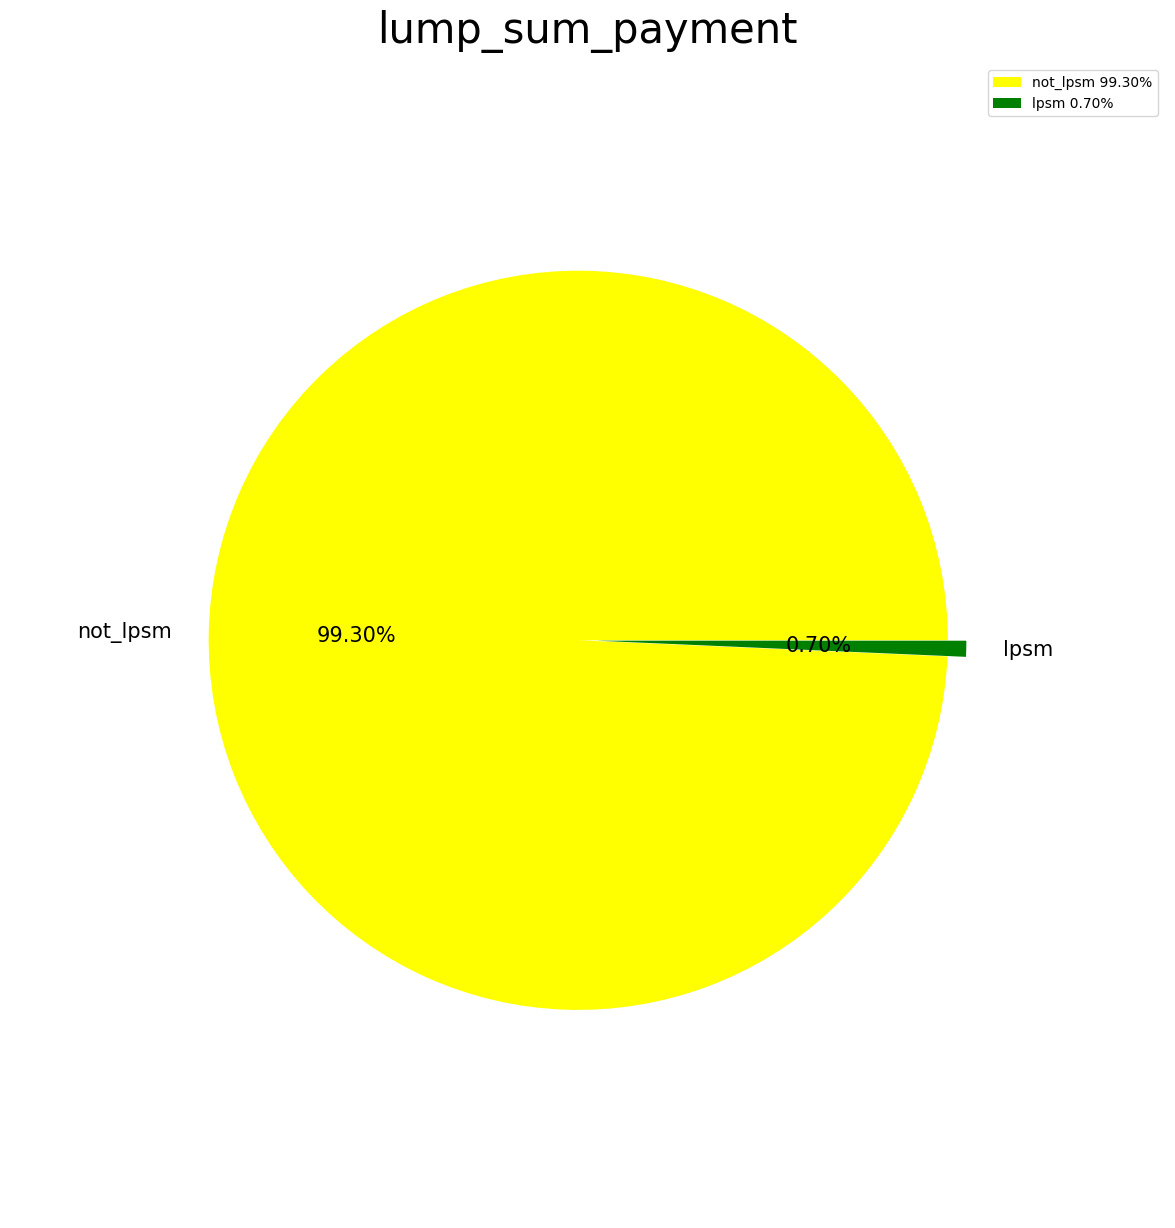

In [26]:
plt.figure(figsize=(18,15))
plt.pie(df['lump_sum_payment'].value_counts().values,labels=df['lump_sum_payment'].value_counts().index,colors=['yellow','green'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('lump_sum_payment',fontsize=30,pad=15)
plt.legend(['not_lpsm 99.30%', 'lpsm 0.70%'])

plt.xticks()
plt.yticks()
plt.show()

In [27]:
df['interest_only'].value_counts()

interest_only
not_int     94120
int_only     4067
Name: count, dtype: int64

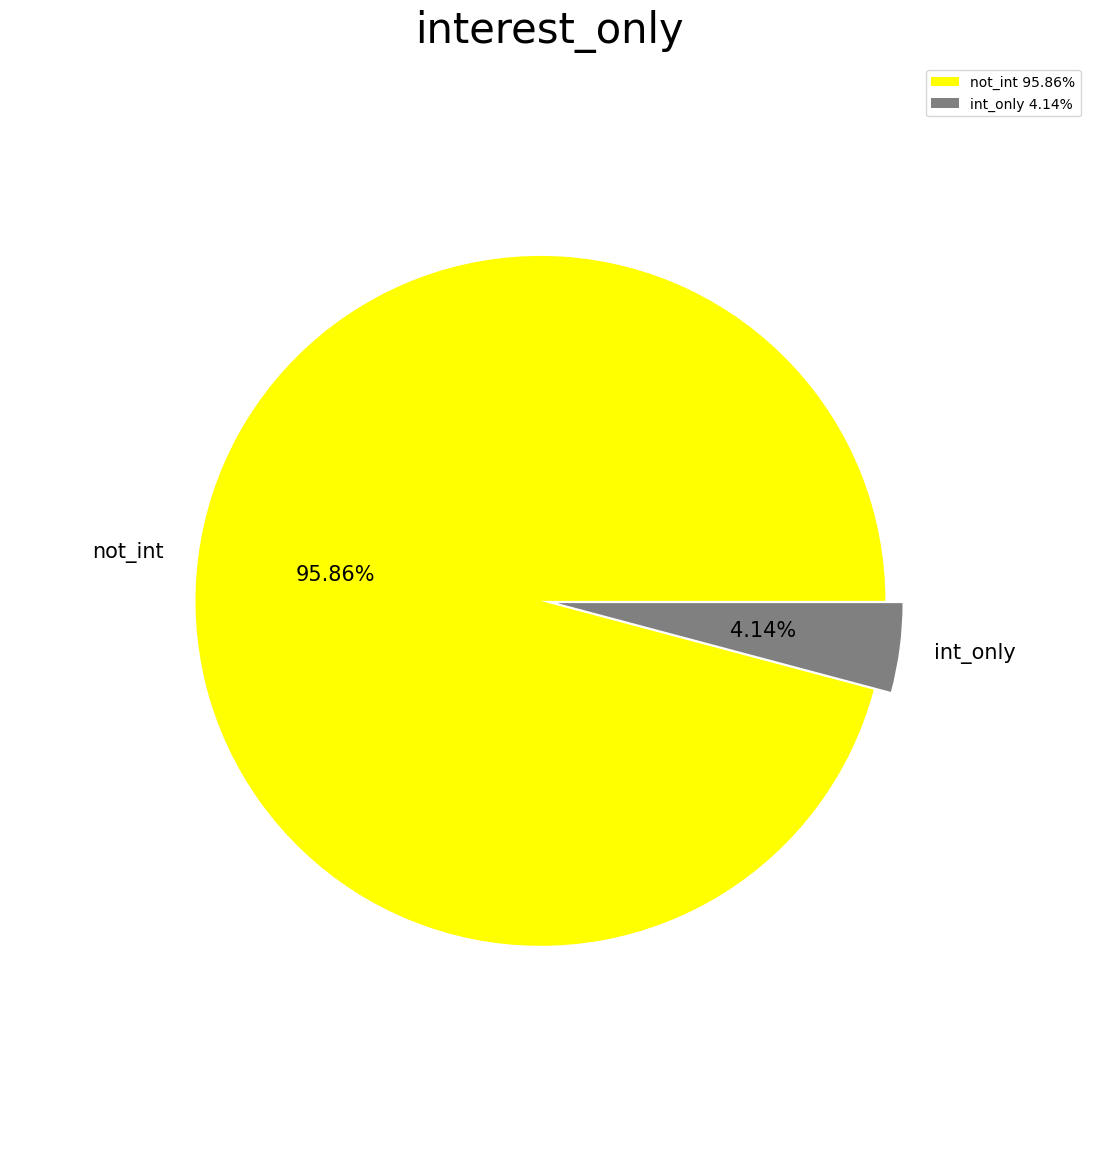

In [28]:
plt.figure(figsize=(18,14))
plt.pie(df['interest_only'].value_counts().values,labels=df['interest_only'].value_counts().index,colors=['yellow','gray'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('interest_only',fontsize=30,pad=15)
plt.legend(['not_int 95.86%', 'int_only 4.14%'])

plt.xticks()
plt.yticks()
plt.show()

In [29]:
df['Neg_ammortization'].value_counts()

Neg_ammortization
not_neg    90328
neg_amm     7859
Name: count, dtype: int64

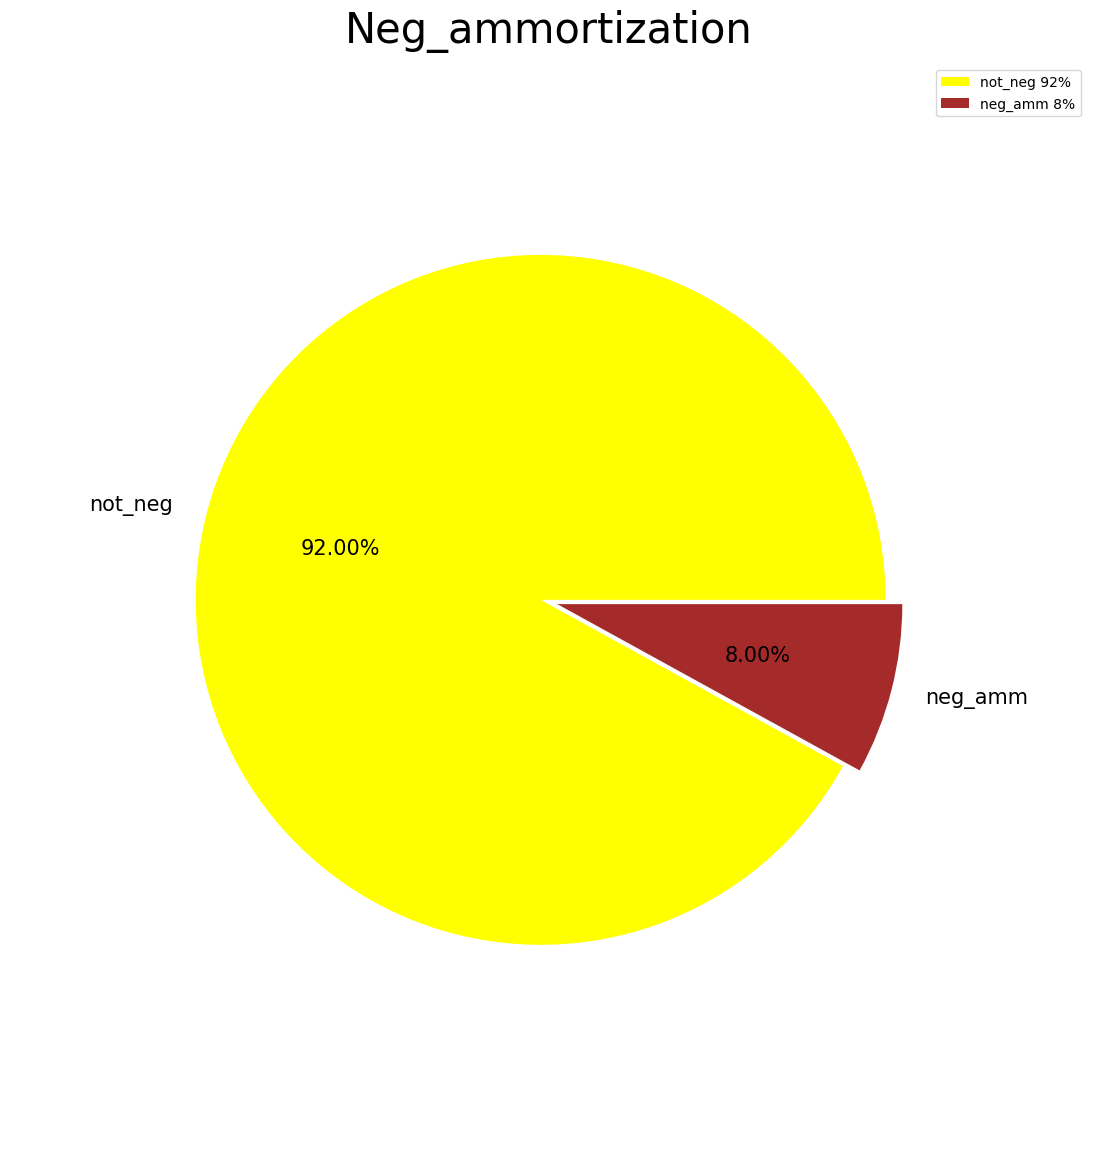

In [30]:
plt.figure(figsize=(18,14))
plt.pie(df['Neg_ammortization'].value_counts().values,labels=df['Neg_ammortization'].value_counts().index,colors=['yellow','brown'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('Neg_ammortization',fontsize=30,pad=15)
plt.legend(['not_neg 92%', 'neg_amm 8%'])

plt.xticks()
plt.yticks()
plt.show()

In [31]:
df['term'].describe()

count    98187.000000
mean       333.658448
std         60.276585
min         96.000000
25%        360.000000
50%        360.000000
75%        360.000000
max        360.000000
Name: term, dtype: float64

In [32]:
df['Upfront_charges'].describe()

count    98187.000000
mean      3389.206553
std       3279.884804
min          0.000000
25%        822.000000
50%       2800.910000
75%       4982.500000
max      60000.000000
Name: Upfront_charges, dtype: float64

In [33]:
df['Interest_rate_spread'].describe()

count    98187.000000
mean         0.466075
std          0.484145
min         -1.039000
25%          0.103000
50%          0.399000
75%          0.774800
max          3.357000
Name: Interest_rate_spread, dtype: float64

In [34]:
df['rate_of_interest'].describe()

count    98187.000000
mean         4.078418
std          0.534448
min          2.125000
25%          3.750000
50%          3.990000
75%          4.500000
max          8.000000
Name: rate_of_interest, dtype: float64

In [35]:
df['loan_amount'].describe()

count    9.818700e+04
mean     3.336575e+05
std      1.750419e+05
min      2.650000e+04
25%      2.065000e+05
50%      3.065000e+05
75%      4.365000e+05
max      3.006500e+06
Name: loan_amount, dtype: float64

In [36]:
df['business_or_commercial'].value_counts()

business_or_commercial
nob/c    88074
b/c      10113
Name: count, dtype: int64

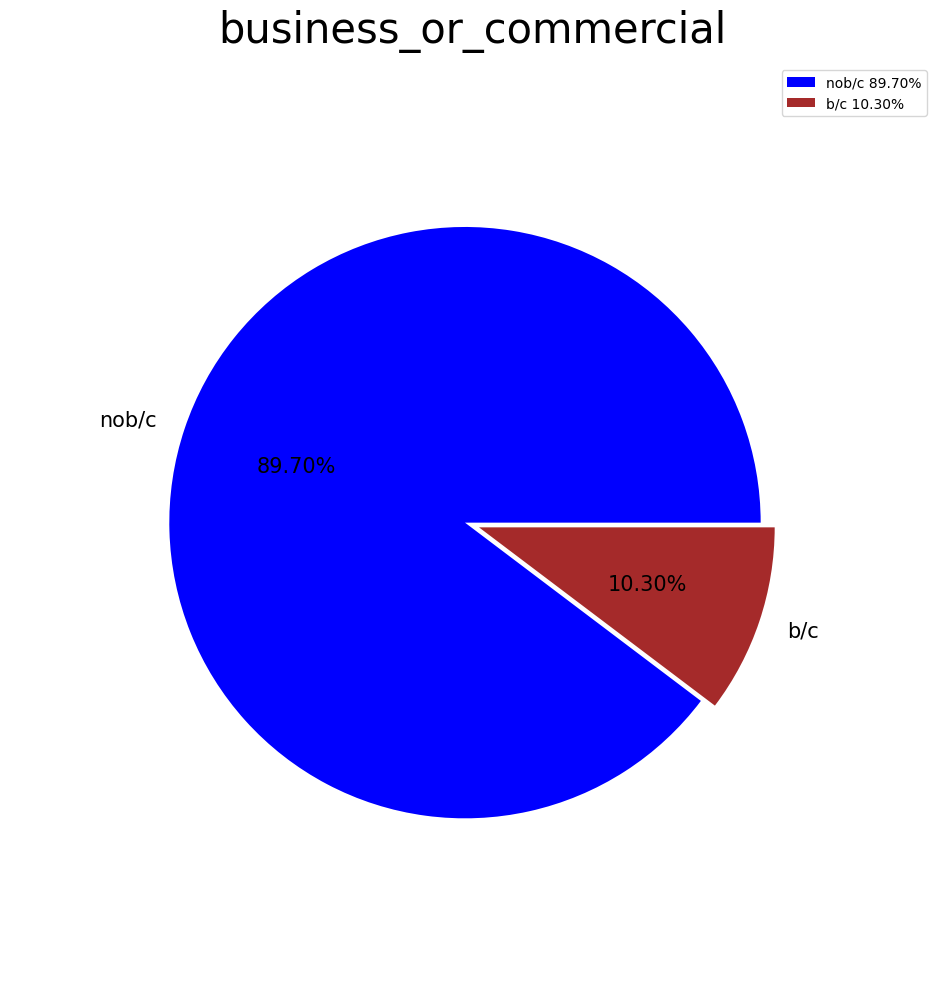

In [37]:
plt.figure(figsize=(16,12))
plt.pie(df['business_or_commercial'].value_counts().values,labels=df['business_or_commercial'].value_counts().index,colors=['blue','brown'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('business_or_commercial',fontsize=30,pad=15)
plt.legend(['nob/c 89.70%', 'b/c 10.30%'])

plt.xticks()
plt.yticks()
plt.show()

In [38]:
df['open_credit'].value_counts()

open_credit
nopc    98187
Name: count, dtype: int64

In [39]:
df['Credit_Worthiness'].value_counts()

Credit_Worthiness
l1    94428
l2     3759
Name: count, dtype: int64

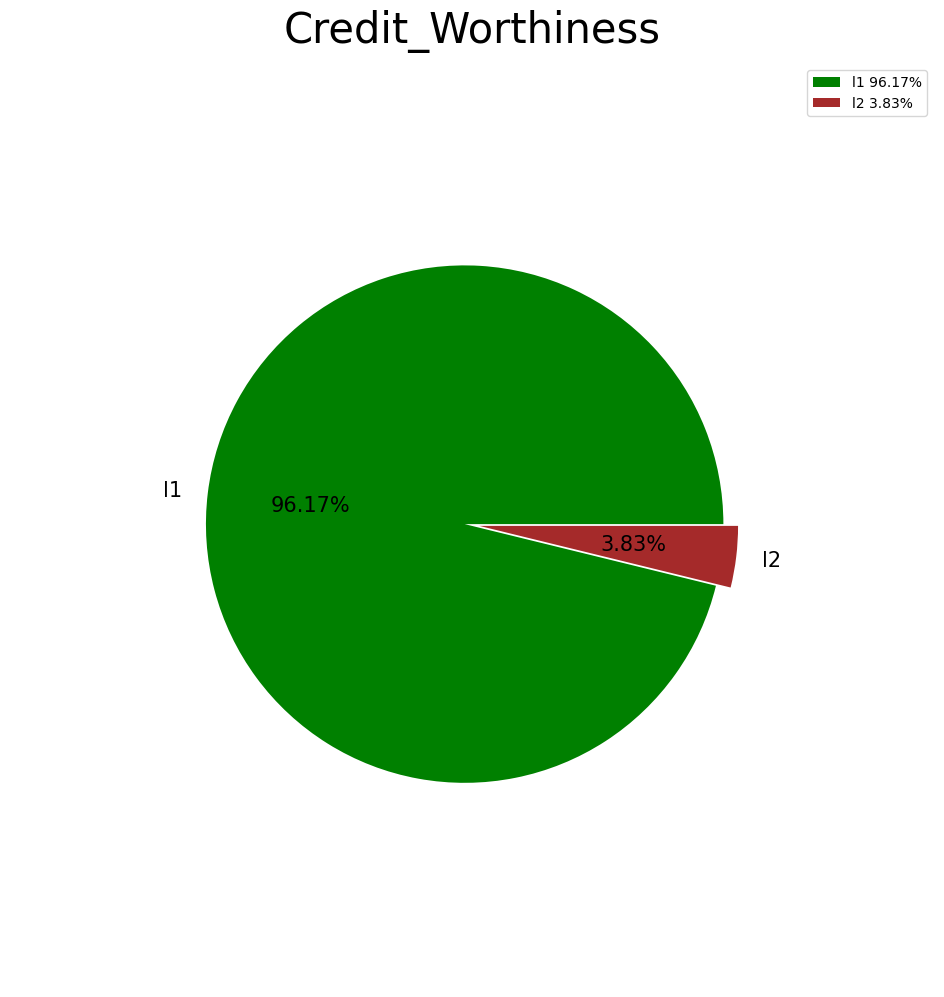

In [40]:
plt.figure(figsize=(16,12))
plt.pie(df['Credit_Worthiness'].value_counts().values,labels=df['Credit_Worthiness'].value_counts().index,colors=['green','brown'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('Credit_Worthiness',fontsize=30,pad=15)
plt.legend(['l1 96.17%', 'l2 3.83%'])

plt.xticks()
plt.yticks()
plt.show()

In [41]:
df['loan_purpose'].value_counts()

loan_purpose
p3    39231
p4    32536
p1    24438
p2     1982
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_5092\1198911181.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['loan_purpose'].value_counts().index,y=df['loan_purpose'].value_counts().values , palette='Set1',width=0.2)


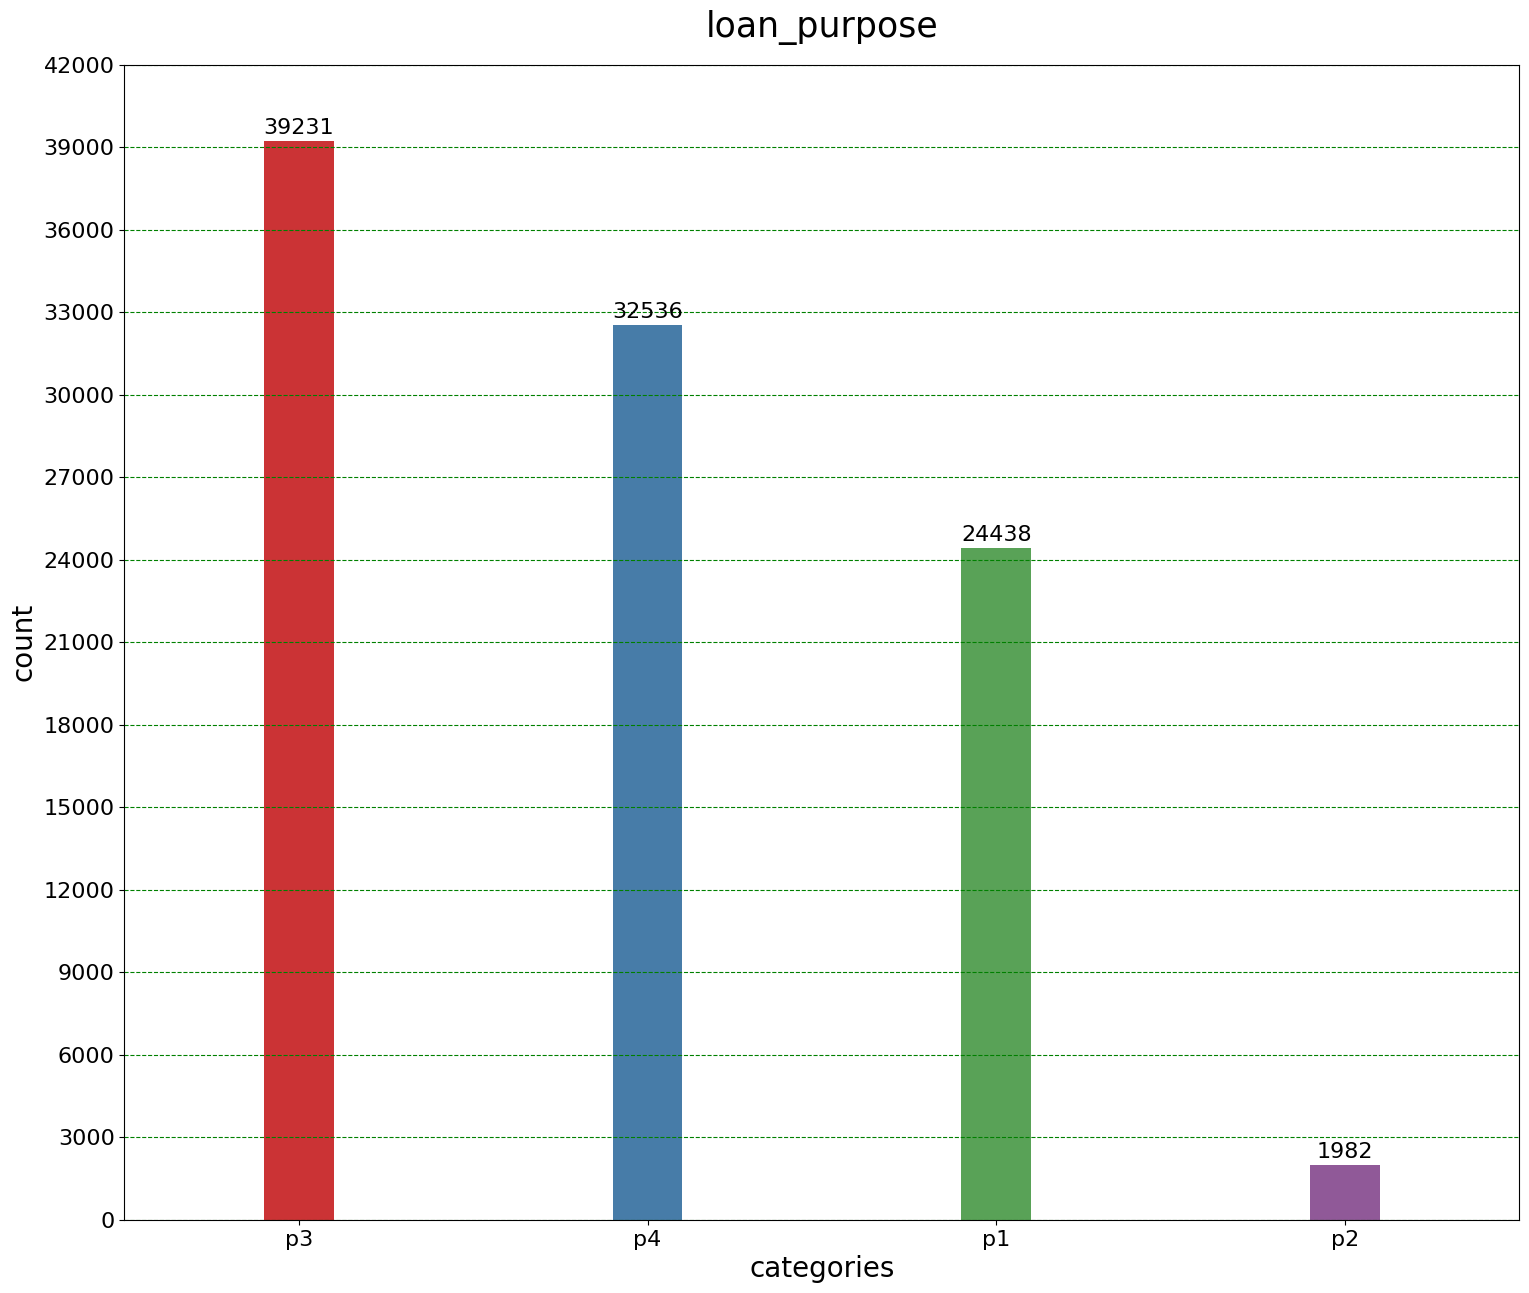

In [42]:
plt.figure(figsize=(18,15))
ax = sns.barplot(x=df['loan_purpose'].value_counts().index,y=df['loan_purpose'].value_counts().values , palette='Set1',width=0.2)
plt.title('loan_purpose',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,43000,3000),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)


plt.show()


In [43]:
df['loan_type'].value_counts()

loan_type
type1    82223
type2    10113
type3     5851
Name: count, dtype: int64

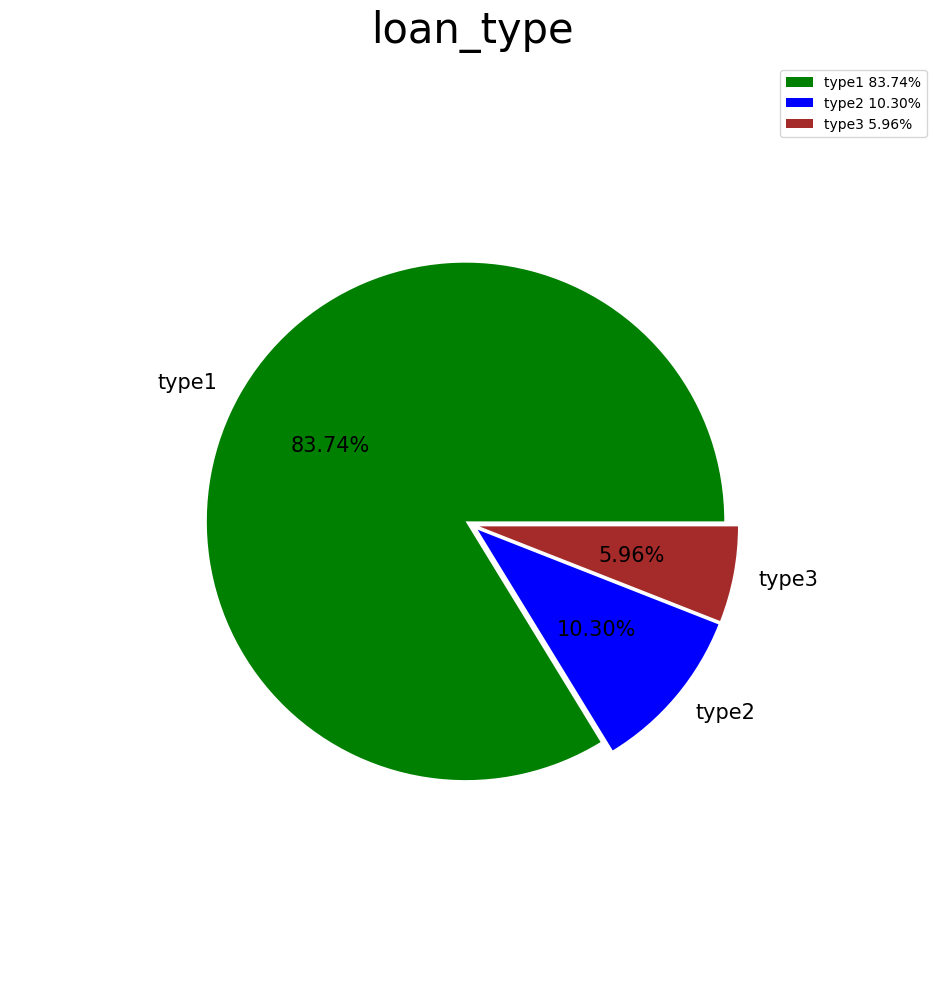

In [44]:
plt.figure(figsize=(16,12))
plt.pie(df['loan_type'].value_counts().values,labels=df['loan_type'].value_counts().index,colors=['green','blue','brown'],explode=[0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('loan_type',fontsize=30,pad=15)
plt.legend(['type1 83.74%', 'type2 10.30%','type3 5.96%'])

plt.xticks()
plt.yticks()
plt.show()

In [45]:
df['approv_in_adv'].value_counts()

approv_in_adv
nopre    81254
pre      16933
Name: count, dtype: int64

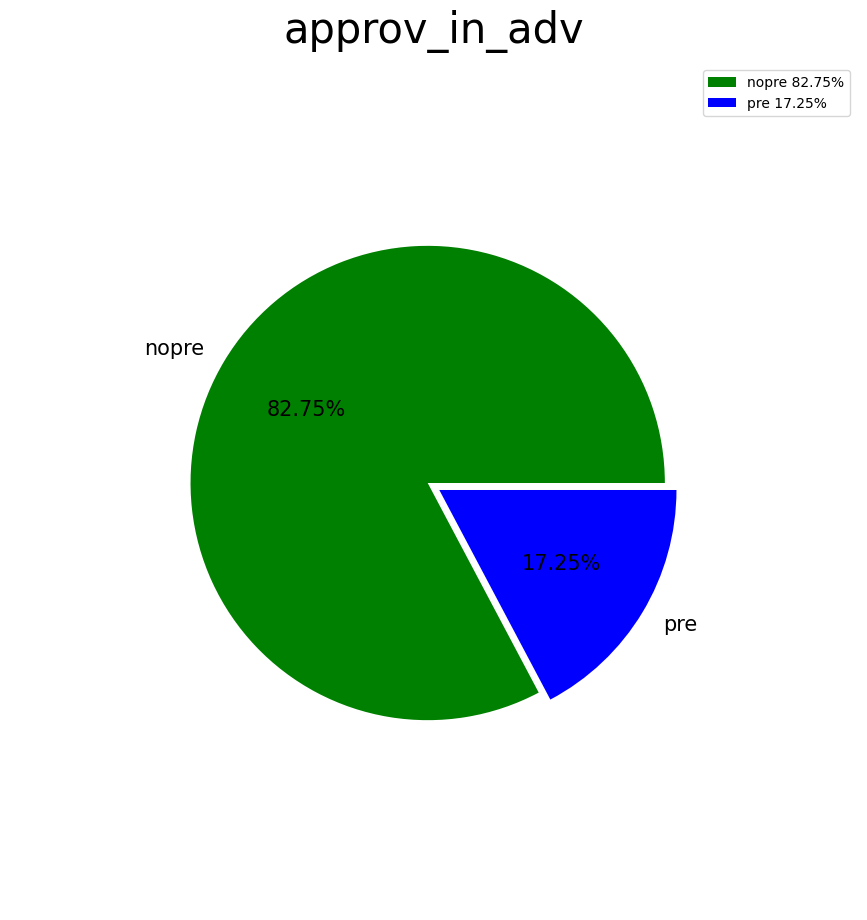

In [46]:
plt.figure(figsize=(16,11))
plt.pie(df['approv_in_adv'].value_counts().values,labels=df['approv_in_adv'].value_counts().index,colors=['green','blue'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('approv_in_adv',fontsize=30,pad=15)
plt.legend(['nopre 82.75%', 'pre 17.25%'])

plt.xticks()
plt.yticks()
plt.show()

In [47]:
df['Gender'].value_counts()

Gender
Joint                29110
Male                 27369
Sex Not Available    23163
Female               18545
Name: count, dtype: int64

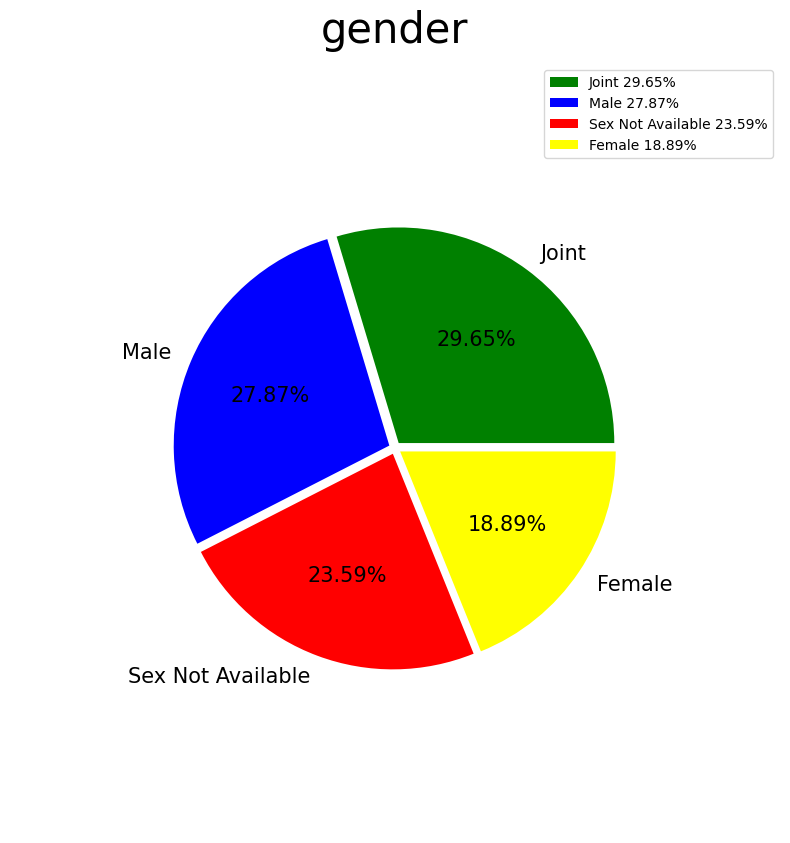

In [48]:
plt.figure(figsize=(16,10))
plt.pie(df['Gender'].value_counts().values,labels=df['Gender'].value_counts().index,colors=['green','blue','red','yellow'],explode=[0.02,0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('gender',fontsize=30,pad=15)
plt.legend(['Joint 29.65%', 'Male 27.87%','Sex Not Available 23.59%','Female 18.89%'])

plt.xticks()
plt.yticks()
plt.show()

In [49]:
df['loan_limit'].value_counts()

loan_limit
cf     92399
ncf     5788
Name: count, dtype: int64

C:\Users\Mega\AppData\Local\Temp\ipykernel_5092\2914901834.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='loan_limit', data=df, palette='Set2',width=0.1)


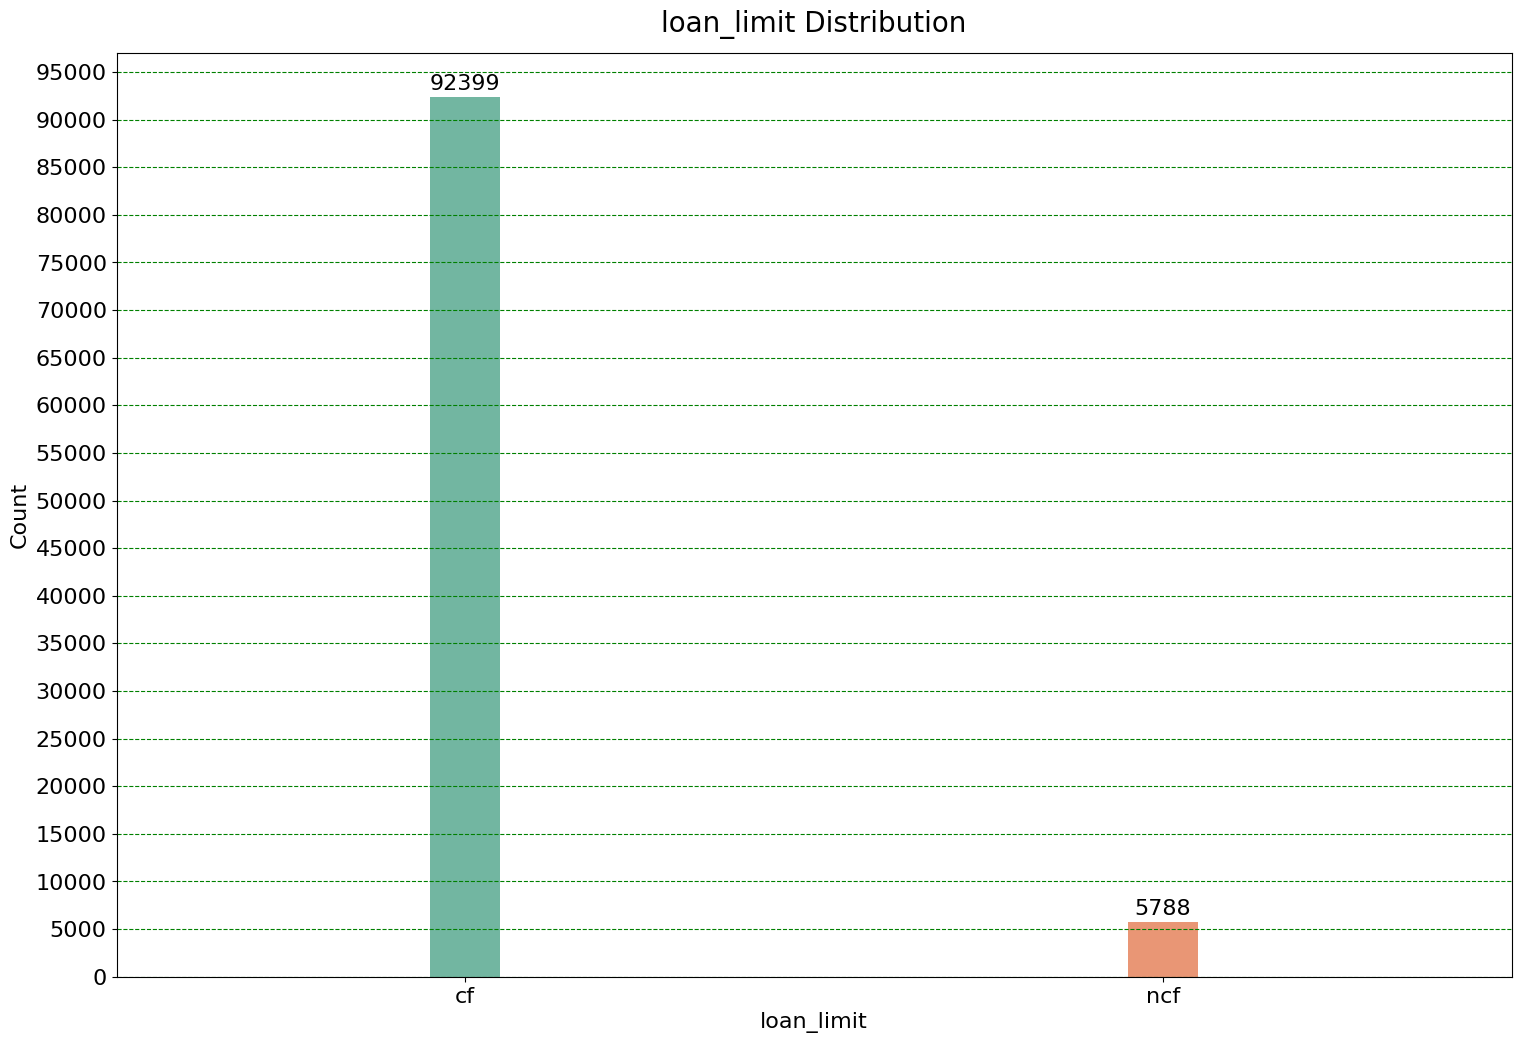

In [50]:
plt.figure(figsize=(18,12))
ax=sns.countplot(x='loan_limit', data=df, palette='Set2',width=0.1) 
plt.title('loan_limit Distribution', fontsize=20, pad=15)
plt.xlabel('loan_limit', fontsize=16) 
plt.ylabel('Count', fontsize=16) 
plt.grid(axis='y', linestyle='--', alpha=1,color='green')
plt.xticks(fontsize=16)
plt.yticks(range(0,100000,5000),fontsize=16)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)
plt.show()

In [51]:
df['year'].describe()

count    98187.0
mean      2019.0
std          0.0
min       2019.0
25%       2019.0
50%       2019.0
75%       2019.0
max       2019.0
Name: year, dtype: float64

In [52]:
df['ID'].describe()

count     98187.000000
mean      99115.912524
std       42951.314090
min       24892.000000
25%       61770.000000
50%       99118.000000
75%      136261.500000
max      173559.000000
Name: ID, dtype: float64

#### **Bivariate Analysis**

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98187 entries, 2 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         98187 non-null  int64  
 1   year                       98187 non-null  int64  
 2   loan_limit                 98187 non-null  object 
 3   Gender                     98187 non-null  object 
 4   approv_in_adv              98187 non-null  object 
 5   loan_type                  98187 non-null  object 
 6   loan_purpose               98187 non-null  object 
 7   Credit_Worthiness          98187 non-null  object 
 8   open_credit                98187 non-null  object 
 9   business_or_commercial     98187 non-null  object 
 10  loan_amount                98187 non-null  int64  
 11  rate_of_interest           98187 non-null  float64
 12  Interest_rate_spread       98187 non-null  float64
 13  Upfront_charges            98187 non-null  float64

In [54]:
print(df.columns)


Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')


# loan_amount + Upfront_charges

In [55]:
T=df[['loan_amount','Upfront_charges']].corr()

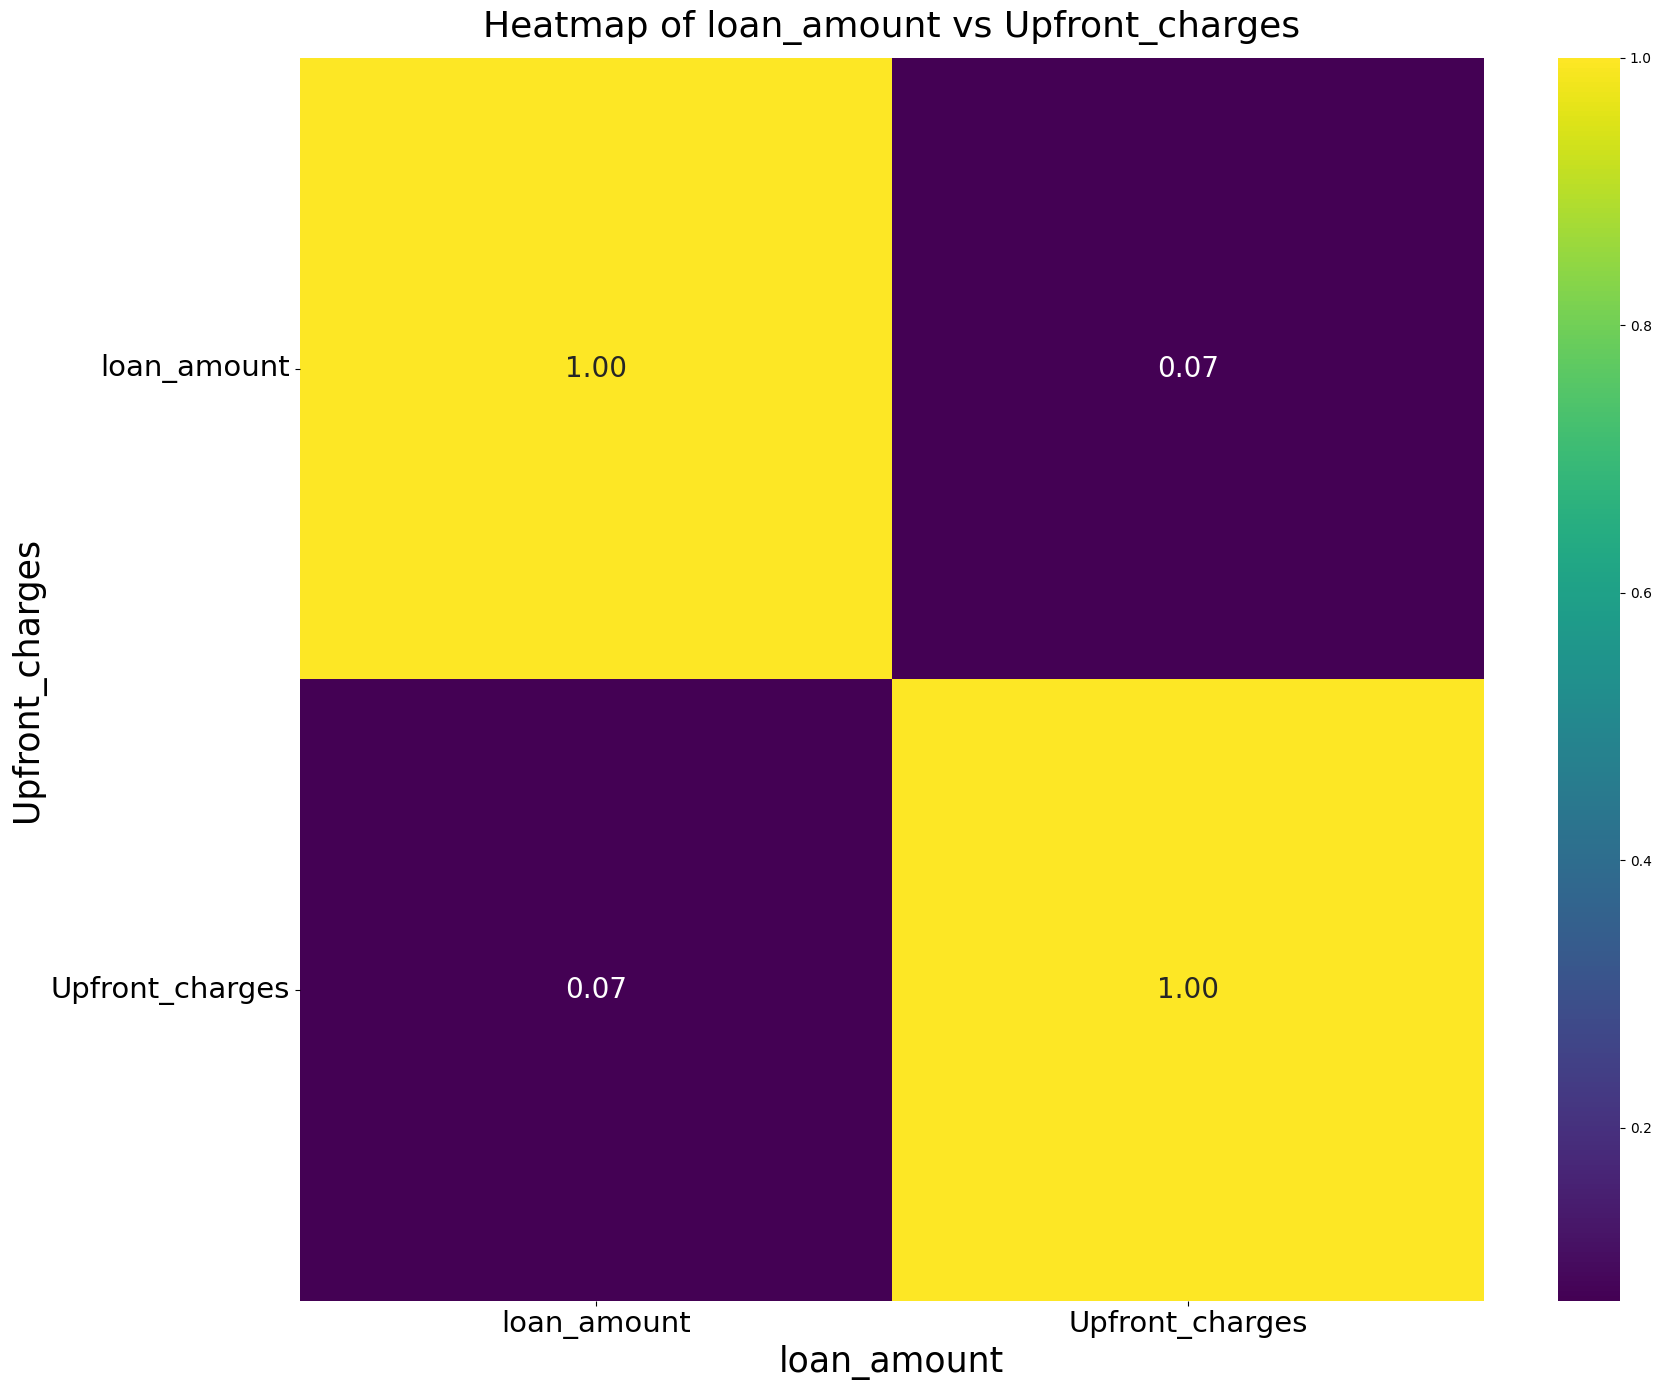

In [56]:
plt.figure(figsize=(18,14))
sns.heatmap(T, annot=True,fmt='.2f', cmap="viridis",annot_kws={"size": 20}) 
plt.title("Heatmap of loan_amount vs Upfront_charges", fontsize=26, pad=15) 
plt.xlabel("loan_amount", fontsize=25)
plt.ylabel("Upfront_charges", fontsize=25) 
plt.xticks(rotation=0,fontsize=21)
plt.yticks(rotation=0,fontsize=21)

plt.tight_layout()
plt.show()



# loan_amount + rate_of_interest

In [57]:
A=df[['loan_amount','rate_of_interest']].corr()

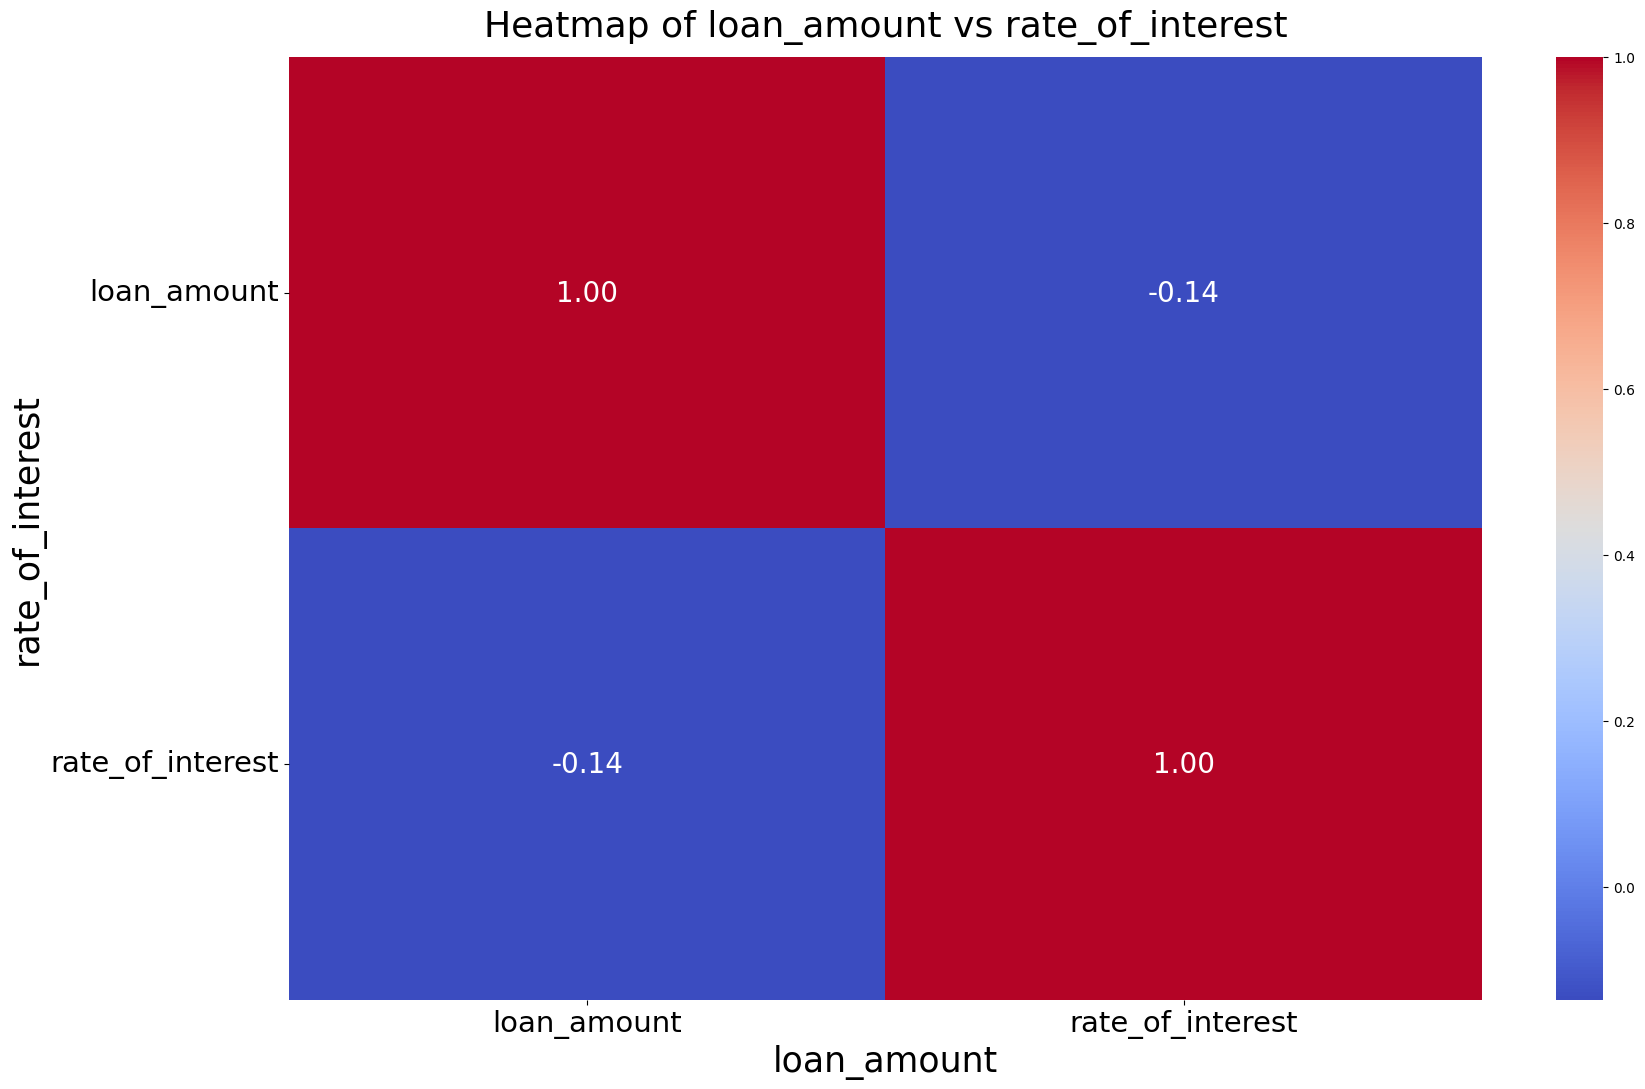

In [58]:
plt.figure(figsize=(18,11))
sns.heatmap(A, annot=True,fmt='.2f', cmap="coolwarm",annot_kws={"size": 20}) 
plt.title("Heatmap of loan_amount vs rate_of_interest", fontsize=26, pad=15) 
plt.xlabel("loan_amount", fontsize=25)
plt.ylabel("rate_of_interest", fontsize=25) 
plt.xticks(rotation=0,fontsize=21)
plt.yticks(rotation=0,fontsize=21)

plt.tight_layout()
plt.show()



# loan_type + loan_limit

In [59]:
R=pd.crosstab(df['loan_type'],df['loan_limit'])

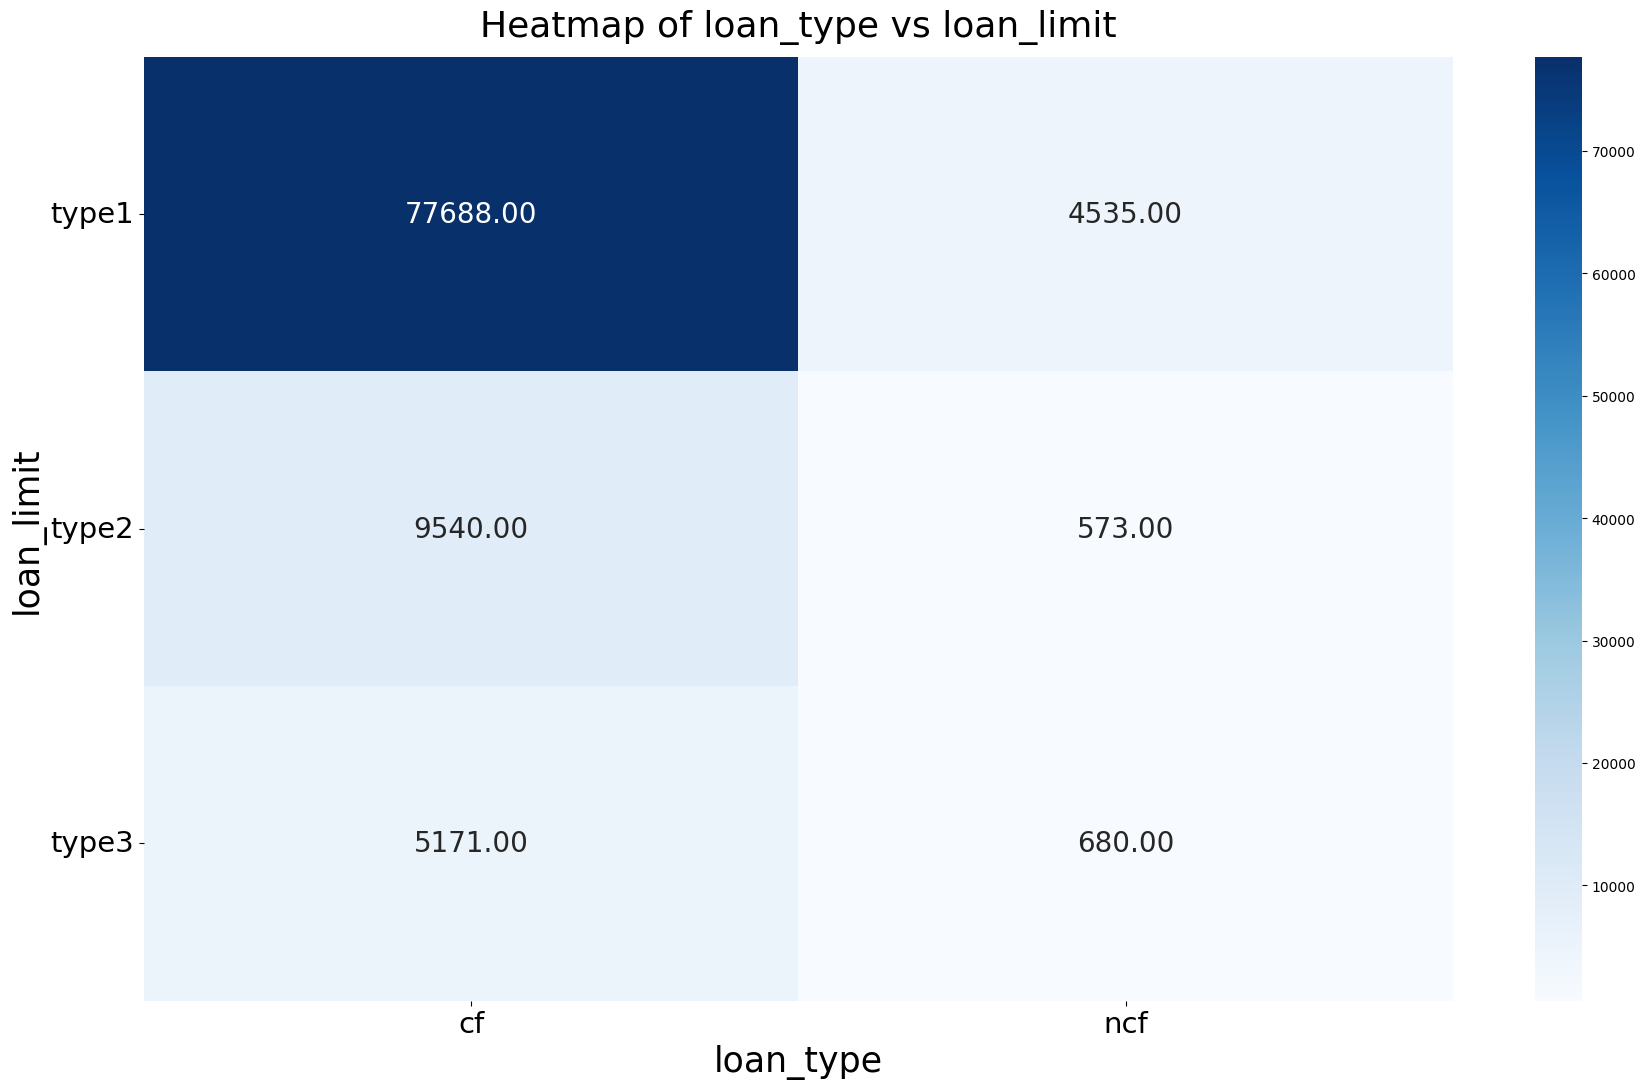

In [60]:
plt.figure(figsize=(18,11))
sns.heatmap(R, annot=True,fmt='.2f', cmap="Blues",annot_kws={"size": 20}) 
plt.title("Heatmap of loan_type vs loan_limit", fontsize=26, pad=15) 
plt.xlabel("loan_type", fontsize=25)
plt.ylabel("loan_limit", fontsize=25) 
plt.xticks(rotation=0,fontsize=21)
plt.yticks(rotation=0,fontsize=21)

plt.tight_layout()
plt.show()



# loan_type + loan_purpose

In [61]:
V=pd.crosstab(df['loan_type'],df['loan_purpose'])

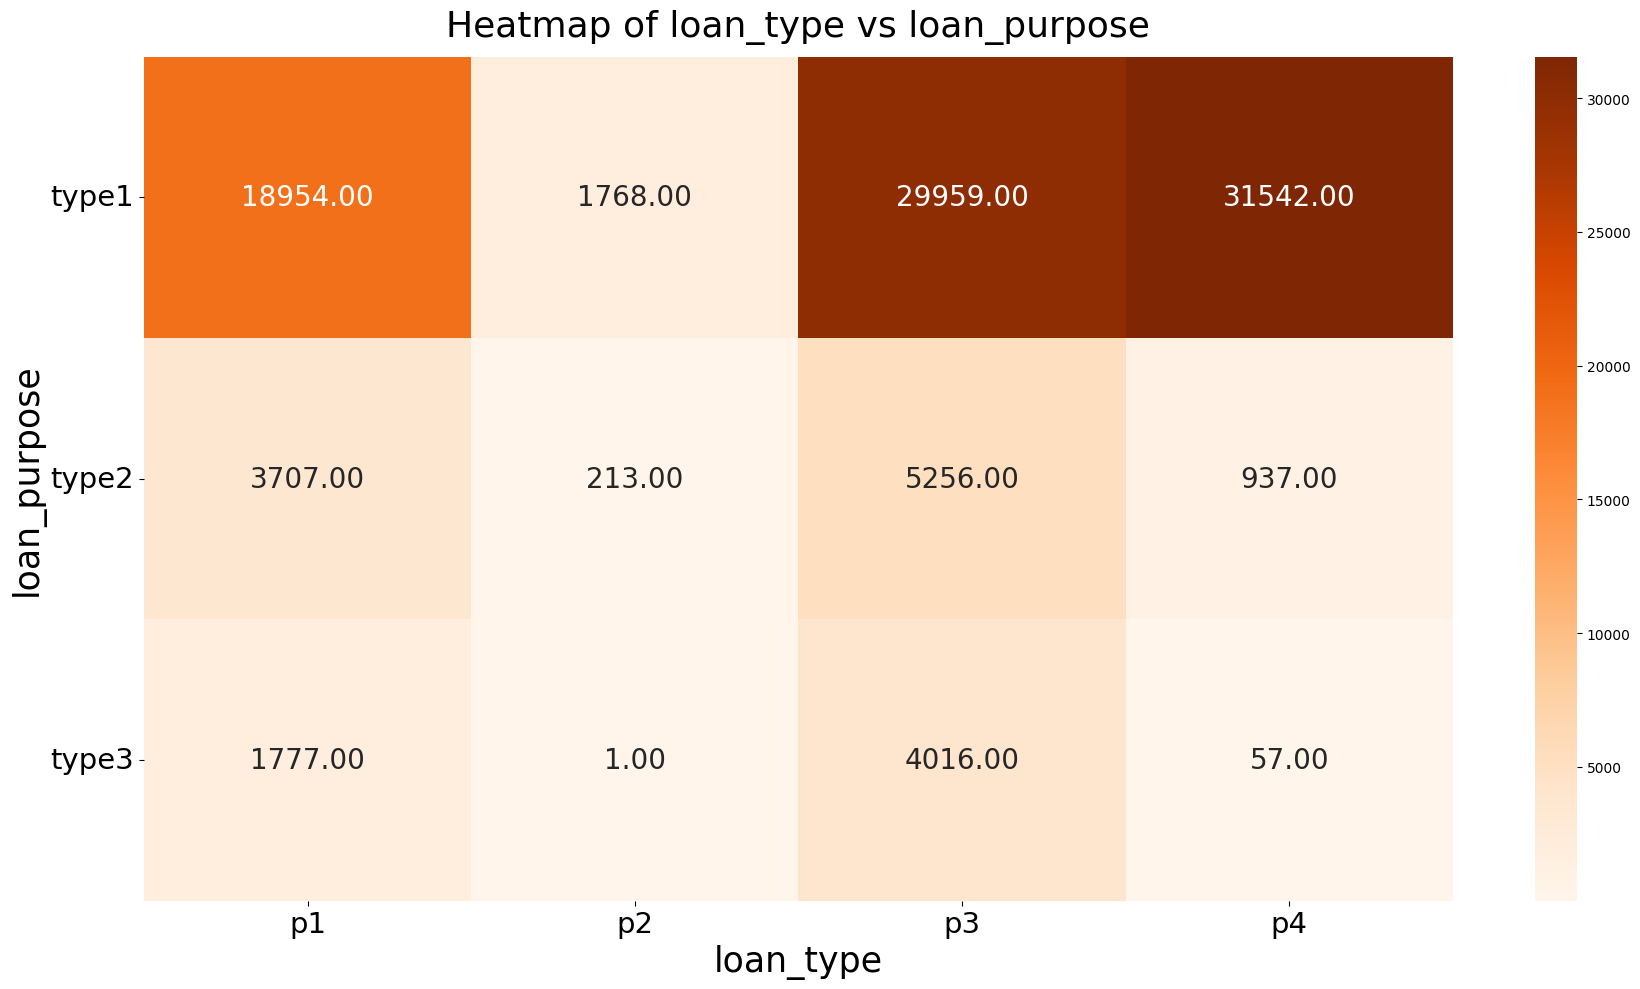

In [62]:
plt.figure(figsize=(18,10))
sns.heatmap(V, annot=True,fmt='.2f', cmap="Oranges",annot_kws={"size": 20}) 
plt.title("Heatmap of loan_type vs loan_purpose", fontsize=26, pad=15) 
plt.xlabel("loan_type", fontsize=25)
plt.ylabel("loan_purpose", fontsize=25) 
plt.xticks(rotation=0,fontsize=21)
plt.yticks(rotation=0,fontsize=21)

plt.tight_layout()
plt.show()



# multivariate analysis

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98187 entries, 2 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         98187 non-null  int64  
 1   year                       98187 non-null  int64  
 2   loan_limit                 98187 non-null  object 
 3   Gender                     98187 non-null  object 
 4   approv_in_adv              98187 non-null  object 
 5   loan_type                  98187 non-null  object 
 6   loan_purpose               98187 non-null  object 
 7   Credit_Worthiness          98187 non-null  object 
 8   open_credit                98187 non-null  object 
 9   business_or_commercial     98187 non-null  object 
 10  loan_amount                98187 non-null  int64  
 11  rate_of_interest           98187 non-null  float64
 12  Interest_rate_spread       98187 non-null  float64
 13  Upfront_charges            98187 non-null  float64

In [64]:
corr=df[['ID','year','loan_amount','rate_of_interest','Interest_rate_spread','Upfront_charges','term','property_value','Status','dtir1']].corr()

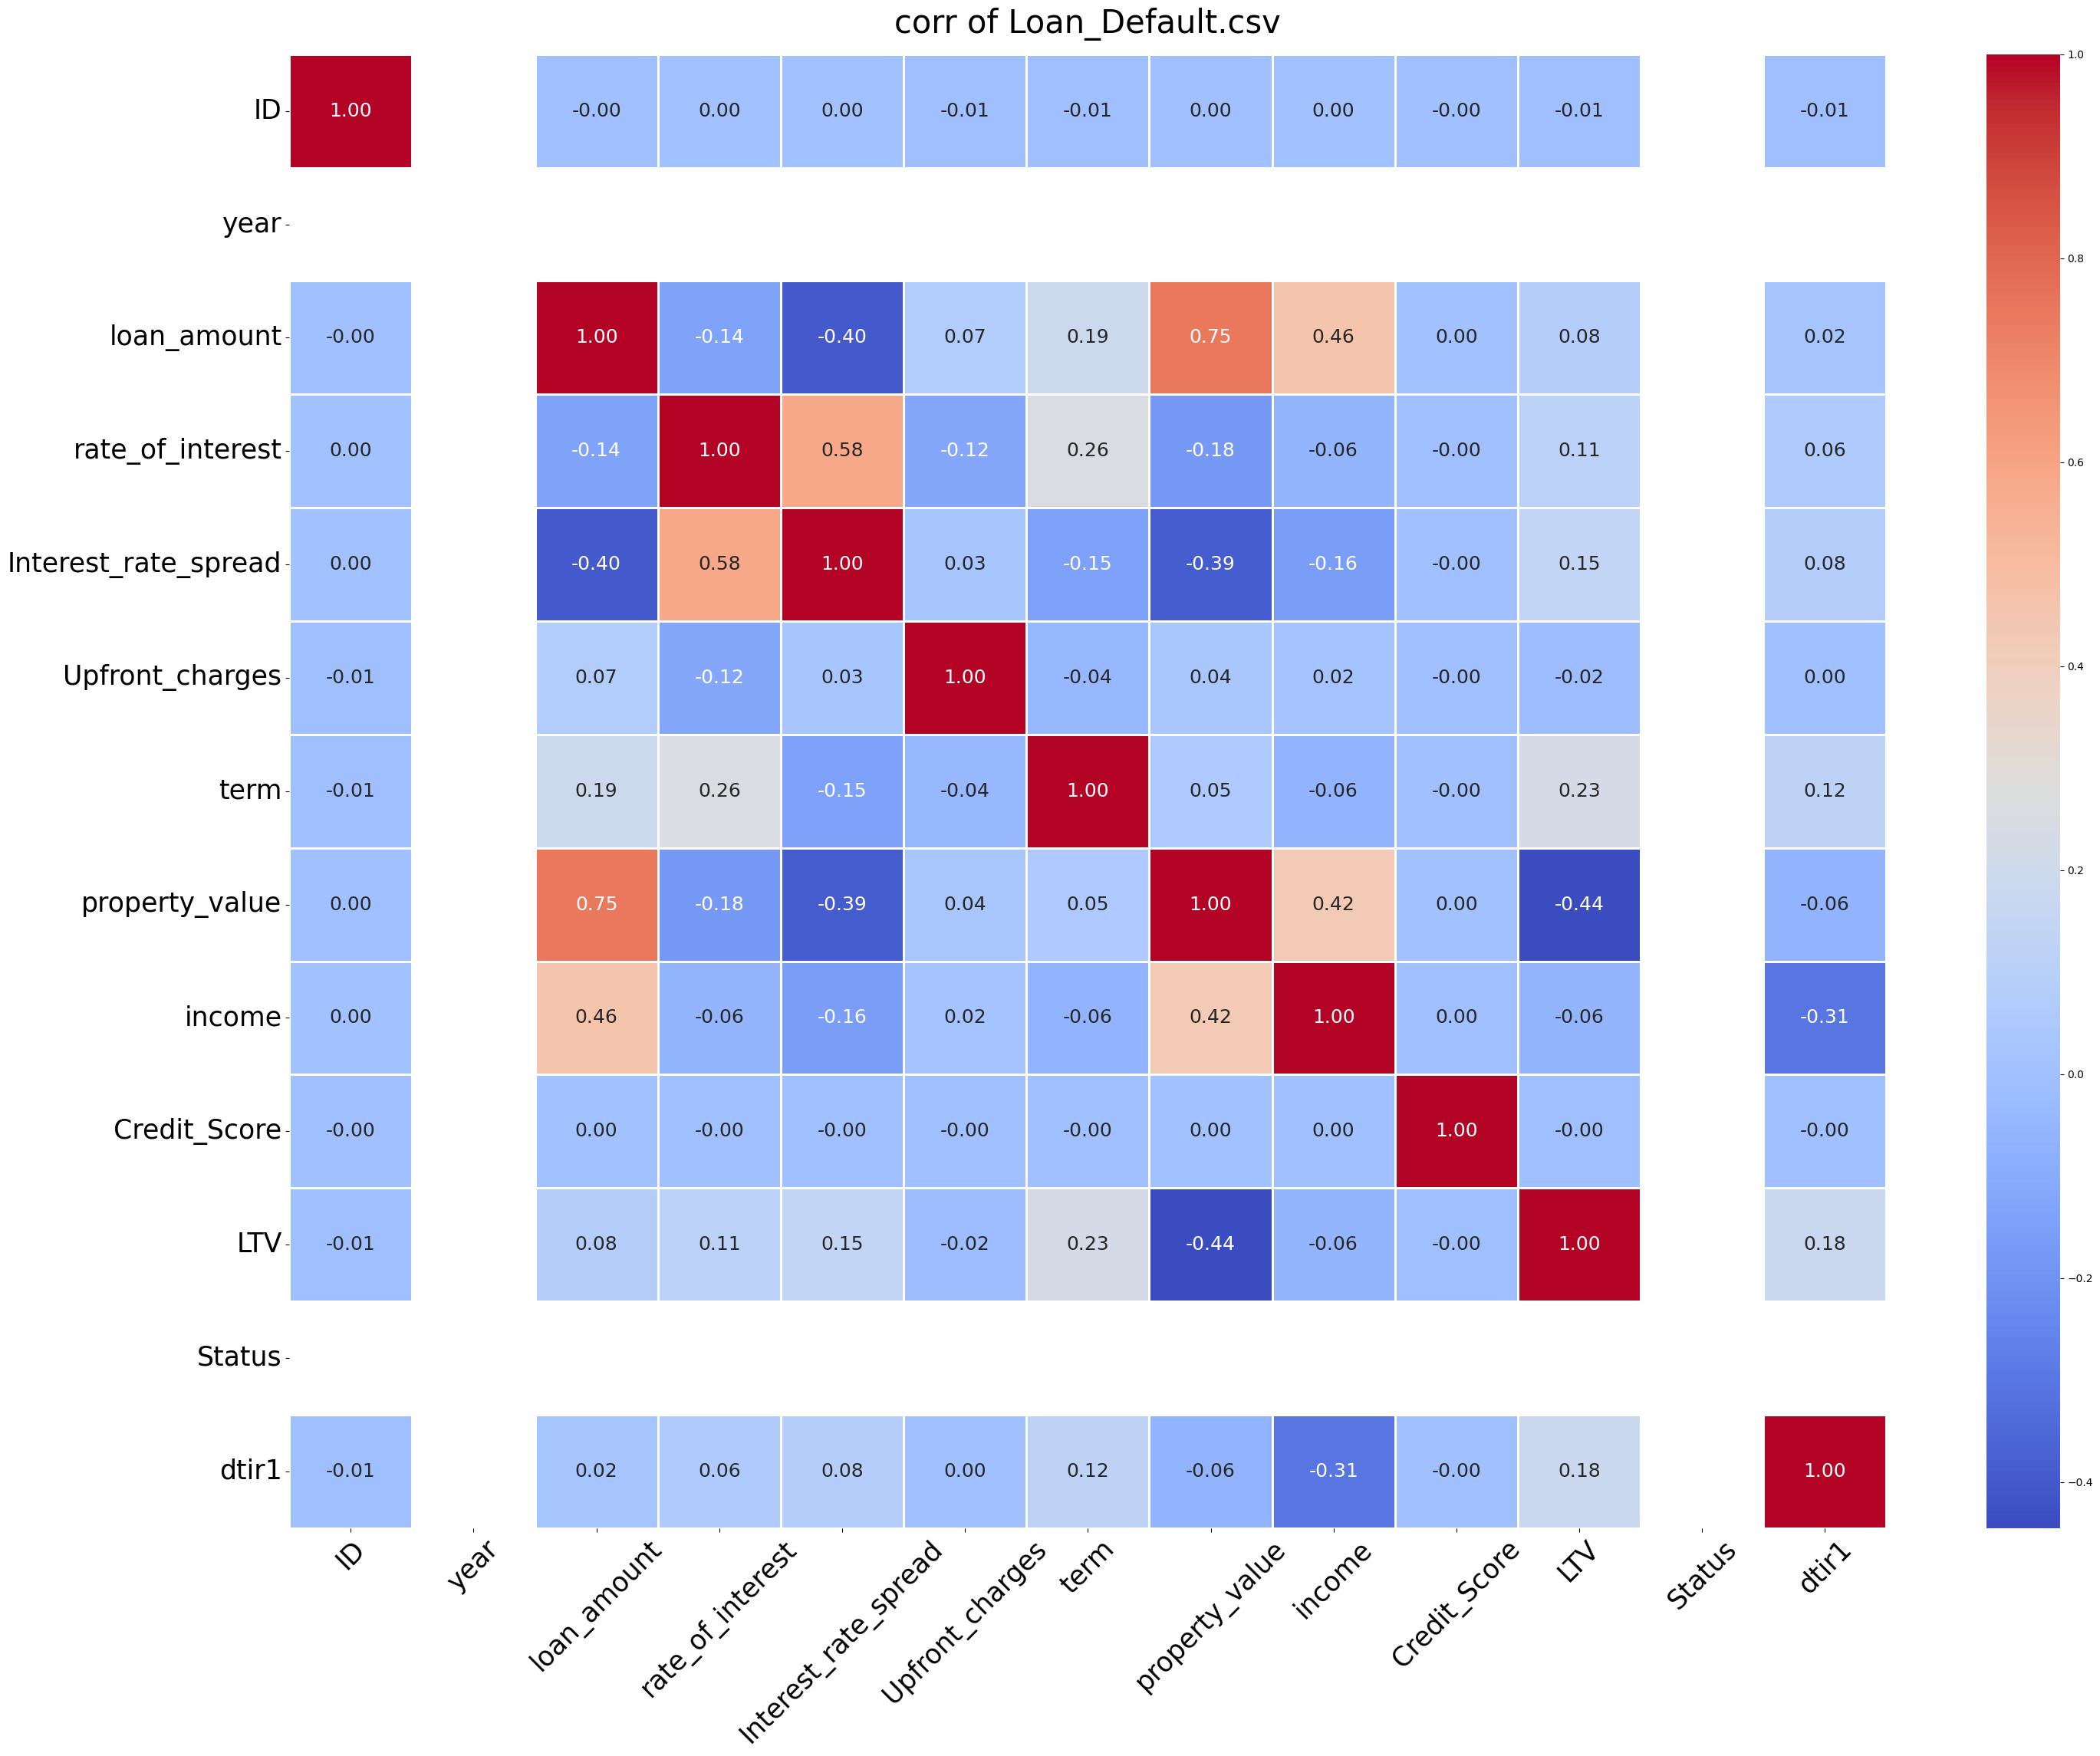

In [65]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(30,23))
sns.heatmap(corr,cmap='coolwarm',annot=True,edgecolor='yellow',linewidths=0.8,fmt='.2f',annot_kws={"size": 18})
plt.title('corr of Loan_Default.csv',fontsize=30,pad=20)
plt.xticks(rotation=45,fontsize=25)
plt.yticks(rotation=0,fontsize=25)

plt.tight_layout()
plt.show()



# loan_amount + rate_of_interest + Upfront_charges

In [66]:
df.groupby(['loan_amount','rate_of_interest'])['Upfront_charges'].value_counts()

loan_amount  rate_of_interest  Upfront_charges
26500        4.125             1025.90            1
             4.250             537.76             1
             4.500             261.30             1
                               562.52             1
             4.625             481.56             1
                                                 ..
2506500      3.250             5185.00            1
             3.500             21524.00           1
2986500      3.990             12328.84           1
3006500      3.125             0.00               1
             3.990             60000.00           1
Name: count, Length: 81678, dtype: int64

<Figure size 2000x1400 with 0 Axes>

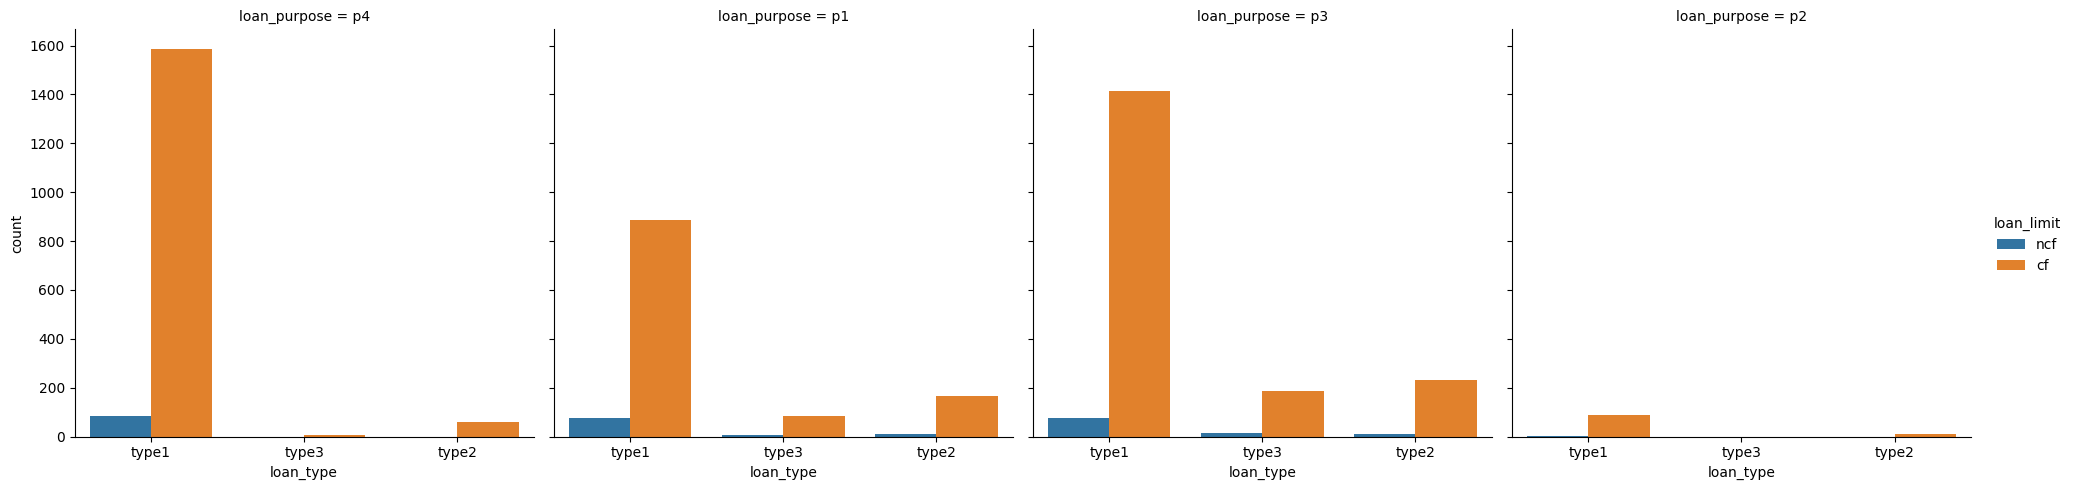

In [67]:
#  عينة عشوائية للرسم فقط
df_sample = df.sample(n=5000, random_state=42)

# استخدم العينة في الرسم بدلاً من df
plt.figure(figsize=(20,14))

sns.catplot(data=df_sample, x='loan_type', hue='loan_limit', col='loan_purpose', kind='count')

C:\Users\Mega\AppData\Local\Temp\ipykernel_5092\2647990.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(x='loan_limit', data=df, palette='Set2',width=0.5)
C:\Users\Mega\AppData\Local\Temp\ipykernel_5092\2647990.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df['loan_purpose'].value_counts().index,y=df['loan_purpose'].value_counts().values , palette='Set1',width=0.5)


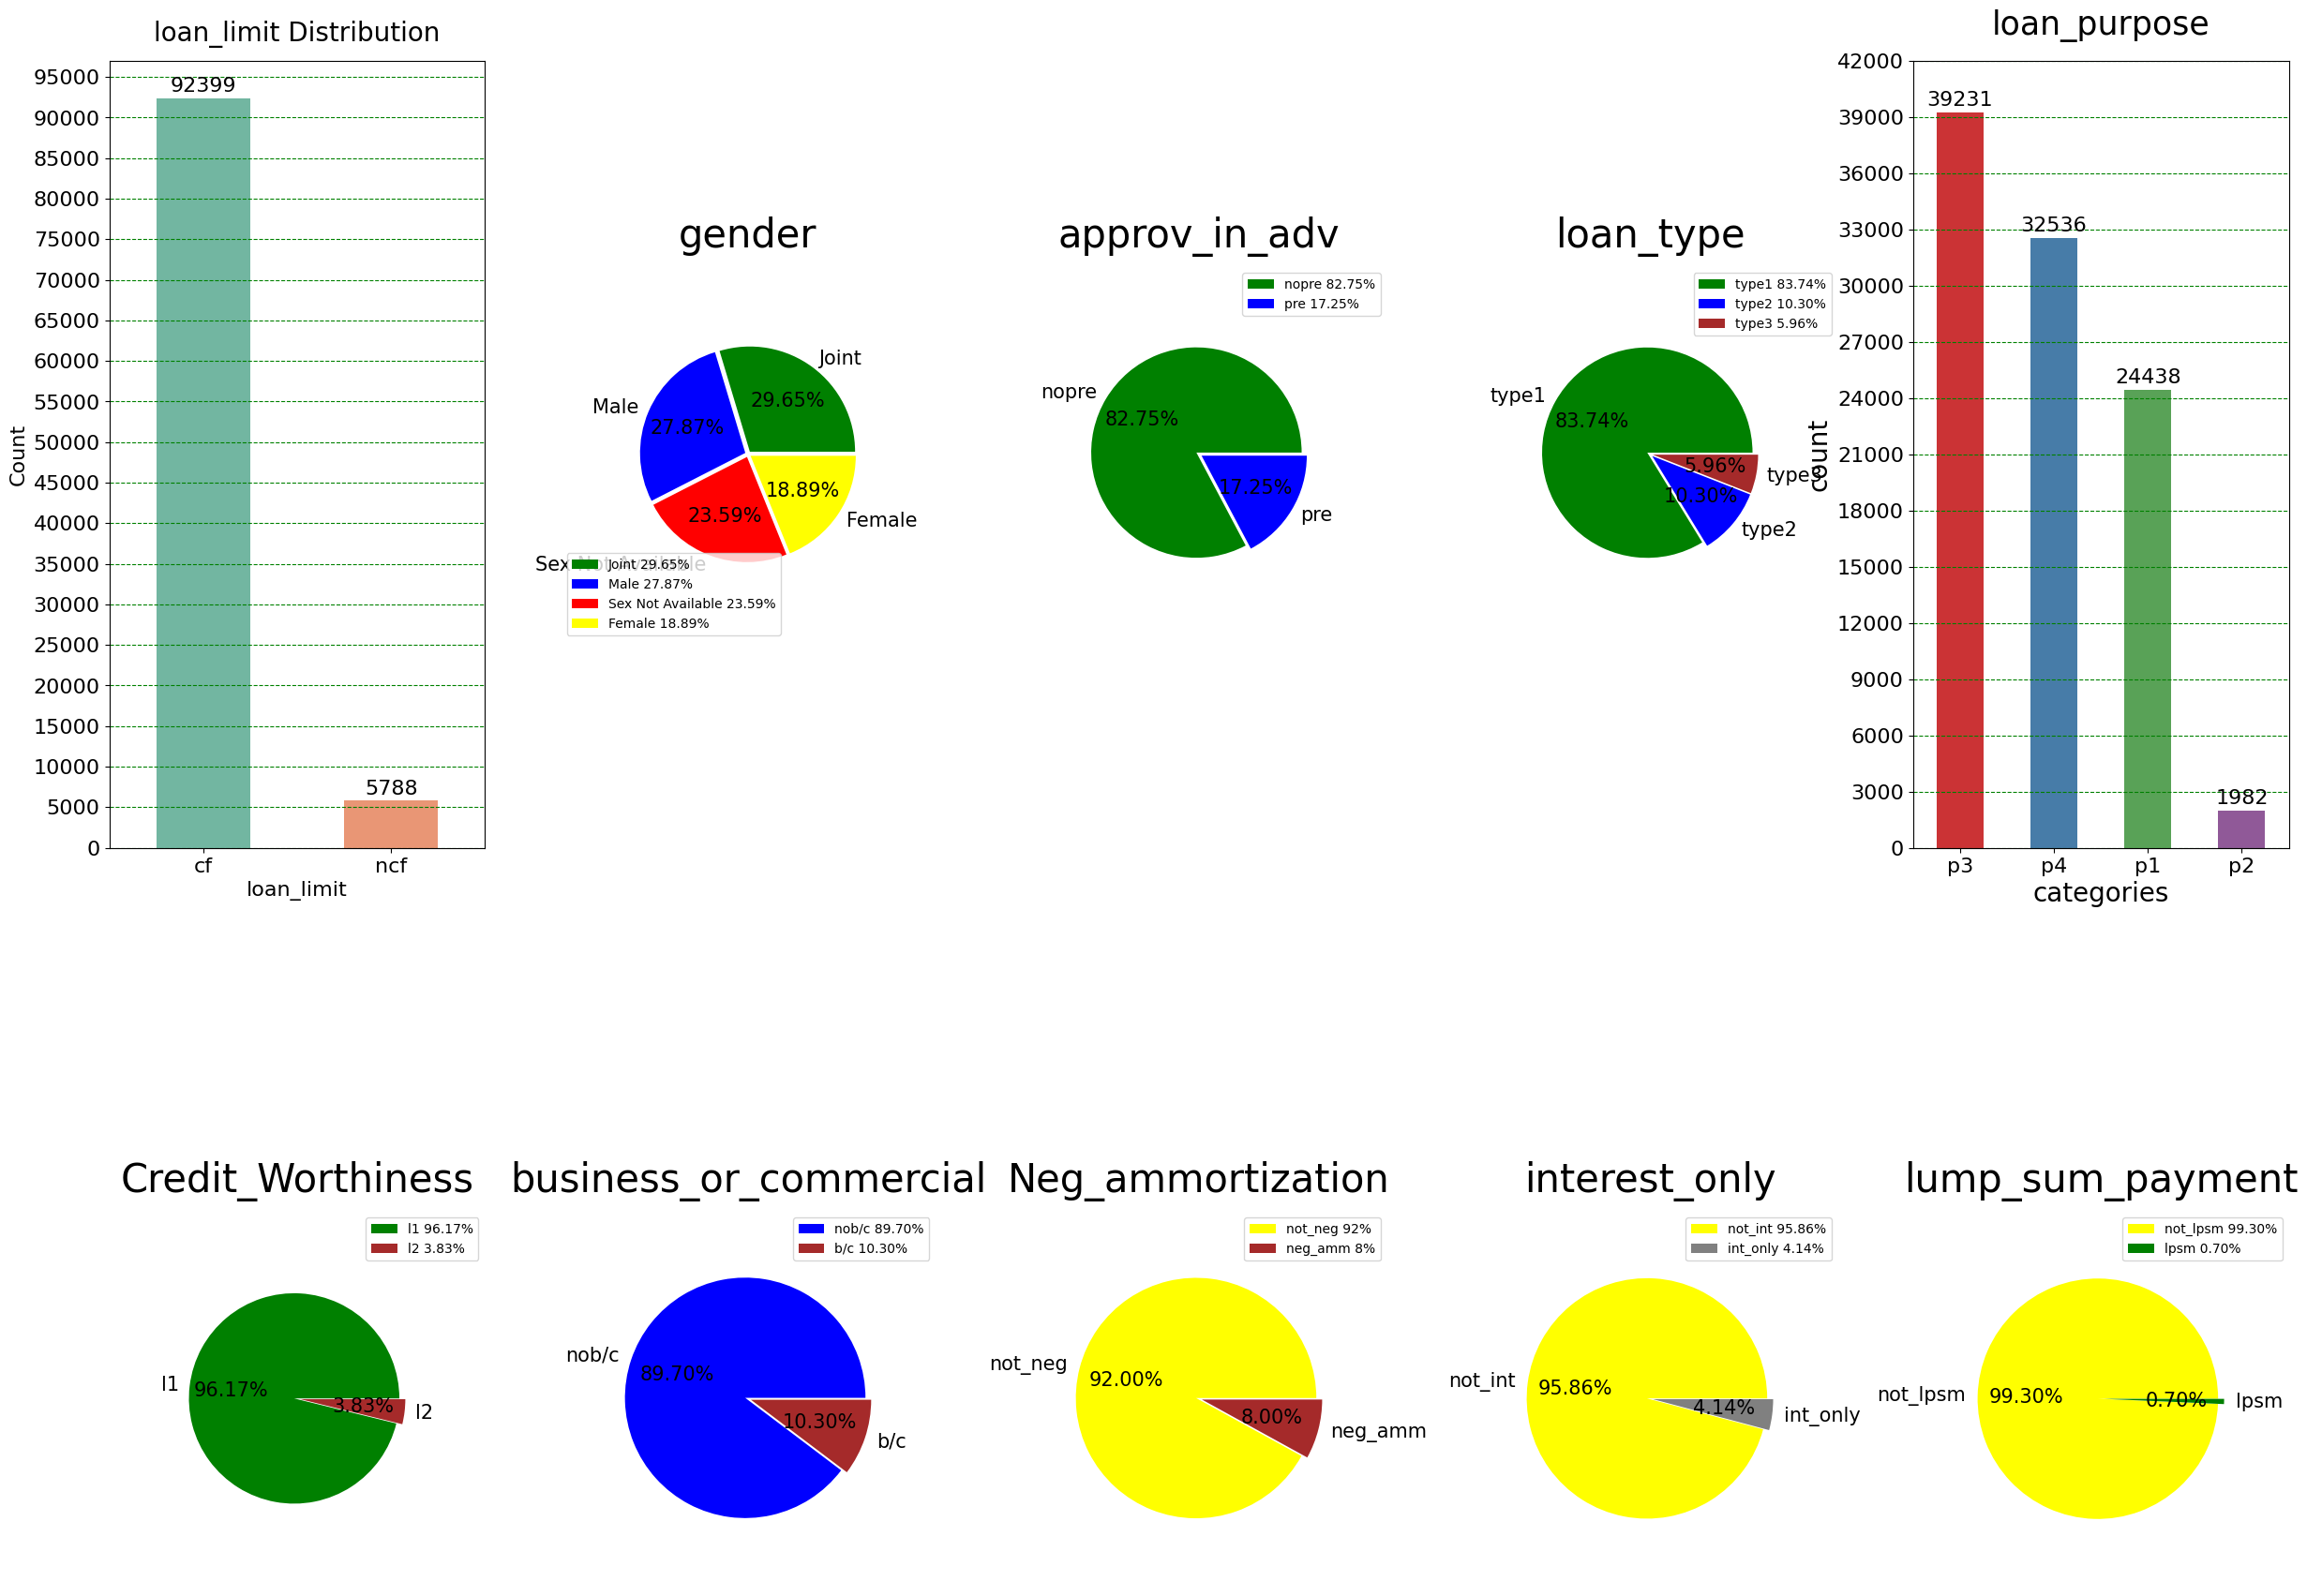

In [68]:
plt.figure(figsize=(30,24))
# subplot 1: countplot for loan_limit
plt.subplot(2,5,1)
ax=sns.countplot(x='loan_limit', data=df, palette='Set2',width=0.5) 
plt.title('loan_limit Distribution', fontsize=20, pad=15)
plt.xlabel('loan_limit', fontsize=16) 
plt.ylabel('Count', fontsize=16) 
plt.grid(axis='y', linestyle='--', alpha=1,color='green')
plt.xticks(fontsize=16)
plt.yticks(range(0,100000,5000),fontsize=16)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)

# subplot 2: pie of gender
plt.subplot(2,5,2)
plt.pie(df['Gender'].value_counts().values,labels=df['Gender'].value_counts().index,colors=['green','blue','red','yellow'],explode=[0.02,0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('gender',fontsize=30,pad=15)
plt.legend(['Joint 29.65%', 'Male 27.87%','Sex Not Available 23.59%','Female 18.89%'])

plt.xticks()
plt.yticks()

# subplot 3: pie of approv_in_adv
plt.subplot(2,5,3)
plt.pie(df['approv_in_adv'].value_counts().values,labels=df['approv_in_adv'].value_counts().index,colors=['green','blue'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('approv_in_adv',fontsize=30,pad=15)
plt.legend(['nopre 82.75%', 'pre 17.25%'])

plt.xticks()
plt.yticks()

# subplot 4: pie of loan_type
plt.subplot(2,5,4)
plt.pie(df['loan_type'].value_counts().values,labels=df['loan_type'].value_counts().index,colors=['green','blue','brown'],explode=[0.02,0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('loan_type',fontsize=30,pad=15)
plt.legend(['type1 83.74%', 'type2 10.30%','type3 5.96%'])

plt.xticks()
plt.yticks()

# subplot 5: bar of loan_purpose
plt.subplot(2,5,5)
ax = sns.barplot(x=df['loan_purpose'].value_counts().index,y=df['loan_purpose'].value_counts().values , palette='Set1',width=0.5)
plt.title('loan_purpose',fontsize=25,pad=20)
plt.xlabel('categories',fontsize=20)
plt.ylabel('count',fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(range(0,43000,3000),fontsize=16)
plt.grid(axis='y',linestyle='--',color='green', alpha=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=16, padding=2)

# subplot 6: pie of Credit_Worthiness
plt.subplot(2,5,6)
plt.pie(df['Credit_Worthiness'].value_counts().values,labels=df['Credit_Worthiness'].value_counts().index,colors=['green','brown'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.7,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('Credit_Worthiness',fontsize=30,pad=15)
plt.legend(['l1 96.17%', 'l2 3.83%'])

plt.xticks()

# subplot 7: pie of business_or_commercial
plt.subplot(2,5,7)
plt.pie(df['business_or_commercial'].value_counts().values,labels=df['business_or_commercial'].value_counts().index,colors=['blue','brown'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('business_or_commercial',fontsize=30,pad=15)
plt.legend(['nob/c 89.70%', 'b/c 10.30%'])

plt.xticks()
plt.yticks()

# subplot 8: pie of Neg_ammortization
plt.subplot(2,5,8)
plt.pie(df['Neg_ammortization'].value_counts().values,labels=df['Neg_ammortization'].value_counts().index,colors=['yellow','brown'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('Neg_ammortization',fontsize=30,pad=15)
plt.legend(['not_neg 92%', 'neg_amm 8%'])

plt.xticks()
plt.yticks()

# subplot 9: pie of interest_only
plt.subplot(2,5,9)
plt.pie(df['interest_only'].value_counts().values,labels=df['interest_only'].value_counts().index,colors=['yellow','gray'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('interest_only',fontsize=30,pad=15)
plt.legend(['not_int 95.86%', 'int_only 4.14%'])

plt.xticks()
plt.yticks()

# subplot 10: pie of lump_sum_payment
plt.subplot(2,5,10)
plt.pie(df['lump_sum_payment'].value_counts().values,labels=df['lump_sum_payment'].value_counts().index,colors=['yellow','green'],explode=[0.02,0.02],
        autopct='%1.2f%%',shadow=False,radius=0.8,counterclock=True,frame=False,rotatelabels=False,textprops={'fontsize':15})
plt.title('lump_sum_payment',fontsize=30,pad=15)
plt.legend(['not_lpsm 99.30%', 'lpsm 0.70%'])

plt.xticks()
plt.yticks()

plt.show()

#### **Drop Unneeded Columns**

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98187 entries, 2 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         98187 non-null  int64  
 1   year                       98187 non-null  int64  
 2   loan_limit                 98187 non-null  object 
 3   Gender                     98187 non-null  object 
 4   approv_in_adv              98187 non-null  object 
 5   loan_type                  98187 non-null  object 
 6   loan_purpose               98187 non-null  object 
 7   Credit_Worthiness          98187 non-null  object 
 8   open_credit                98187 non-null  object 
 9   business_or_commercial     98187 non-null  object 
 10  loan_amount                98187 non-null  int64  
 11  rate_of_interest           98187 non-null  float64
 12  Interest_rate_spread       98187 non-null  float64
 13  Upfront_charges            98187 non-null  float64

In [70]:
df.drop(columns=['ID','year','open_credit','Interest_rate_spread','term','Status','dtir1','Upfront_charges','lump_sum_payment','property_value','construction_type','occupancy_type','Secured_by','loan_type','Credit_Worthiness'],inplace=True)

In [71]:
df

,loan_limit,Gender,approv_in_adv,loan_purpose,business_or_commercial,loan_amount,rate_of_interest,Neg_ammortization,interest_only,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type
2,cf,Male,pre,p1,nob/c,406500,4.560,neg_amm,not_int,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct
4,cf,Joint,pre,p1,nob/c,696500,4.000,not_neg,not_int,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct
5,cf,Joint,pre,p1,nob/c,706500,3.990,not_neg,not_int,1U,10080.0,EXP,864,EXP,35-44,not_inst,70.089286,North,direct
6,cf,Joint,pre,p3,nob/c,346500,4.500,not_neg,not_int,1U,5040.0,EXP,860,EXP,55-64,to_inst,79.109589,North,direct
8,cf,Joint,nopre,p3,nob/c,376500,4.875,not_neg,not_int,1U,5580.0,CIB,580,EXP,55-64,to_inst,78.765690,central,direct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,cf,Sex Not Available,nopre,p3,nob/c,436500,3.125,not_neg,not_int,1U,7860.0,CIB,659,EXP,55-64,to_inst,71.792763,south,direct
148666,cf,Male,nopre,p1,nob/c,586500,5.190,not_neg,not_int,4U,7140.0,CIB,569,CIB,25-34,not_inst,74.428934,south,direct
148667,cf,Male,nopre,p4,nob/c,446500,3.125,not_neg,not_int,1U,6900.0,CIB,702,EXP,45-54,not_inst,61.332418,North,direct
148668,cf,Female,nopre,p4,nob/c,196500,3.500,not_neg,not_int,1U,7140.0,EXP,737,EXP,55-64,to_inst,70.683453,North,direct


#### **x and y**

In [72]:
x=df.drop('loan_purpose',axis=1)
y=df[['loan_purpose']]

In [73]:
x

,loan_limit,Gender,approv_in_adv,business_or_commercial,loan_amount,rate_of_interest,Neg_ammortization,interest_only,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type
2,cf,Male,pre,nob/c,406500,4.560,neg_amm,not_int,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct
4,cf,Joint,pre,nob/c,696500,4.000,not_neg,not_int,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct
5,cf,Joint,pre,nob/c,706500,3.990,not_neg,not_int,1U,10080.0,EXP,864,EXP,35-44,not_inst,70.089286,North,direct
6,cf,Joint,pre,nob/c,346500,4.500,not_neg,not_int,1U,5040.0,EXP,860,EXP,55-64,to_inst,79.109589,North,direct
8,cf,Joint,nopre,nob/c,376500,4.875,not_neg,not_int,1U,5580.0,CIB,580,EXP,55-64,to_inst,78.765690,central,direct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,cf,Sex Not Available,nopre,nob/c,436500,3.125,not_neg,not_int,1U,7860.0,CIB,659,EXP,55-64,to_inst,71.792763,south,direct
148666,cf,Male,nopre,nob/c,586500,5.190,not_neg,not_int,4U,7140.0,CIB,569,CIB,25-34,not_inst,74.428934,south,direct
148667,cf,Male,nopre,nob/c,446500,3.125,not_neg,not_int,1U,6900.0,CIB,702,EXP,45-54,not_inst,61.332418,North,direct
148668,cf,Female,nopre,nob/c,196500,3.500,not_neg,not_int,1U,7140.0,EXP,737,EXP,55-64,to_inst,70.683453,North,direct


In [74]:
y

,loan_purpose
2,p1
4,p1
5,p1
6,p3
8,p3
...,...
148665,p3
148666,p1
148667,p4
148668,p4


# label encoder

In [75]:
encoder=LabelEncoder()
x['loan_limit']=encoder.fit_transform(x['loan_limit'])
x['Gender']=encoder.fit_transform(x['Gender'])
x['approv_in_adv']=encoder.fit_transform(x['approv_in_adv'])
x['business_or_commercial']=encoder.fit_transform(x['business_or_commercial'])
x['Neg_ammortization']=encoder.fit_transform(x['Neg_ammortization'])
x['interest_only']=encoder.fit_transform(x['interest_only'])
x['total_units']=encoder.fit_transform(x['total_units'])
x['credit_type']=encoder.fit_transform(x['credit_type'])
x['co-applicant_credit_type']=encoder.fit_transform(x['co-applicant_credit_type'])
x['submission_of_application']=encoder.fit_transform(x['submission_of_application'])
x['Region']=encoder.fit_transform(x['Region'])
x['Security_Type']=encoder.fit_transform(x['Security_Type'])
x['loan_amount']=encoder.fit_transform(x['loan_amount'])
x['rate_of_interest']=encoder.fit_transform(x['rate_of_interest'])
x['income']=encoder.fit_transform(x['income'])
x['Credit_Score']=encoder.fit_transform(x['Credit_Score'])
x['age']=encoder.fit_transform(x['age'])
x['LTV']=encoder.fit_transform(x['LTV'])




In [76]:
encoder = LabelEncoder() 
y['loan_purpose'] = encoder.fit_transform(y['loan_purpose'])


C:\Users\Mega\AppData\Local\Temp\ipykernel_5092\2298973619.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['loan_purpose'] = encoder.fit_transform(y['loan_purpose'])


In [77]:
x

,loan_limit,Gender,approv_in_adv,business_or_commercial,loan_amount,rate_of_interest,Neg_ammortization,interest_only,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type
2,0,2,1,1,38,92,0,1,0,152,3,334,0,1,1,6224,3,0
4,0,1,1,1,67,68,1,1,0,168,1,102,1,0,0,6745,0,0
5,0,1,1,1,68,67,1,1,0,162,3,364,1,1,0,5501,0,0
6,0,1,1,1,32,89,1,1,0,78,3,360,1,3,1,6127,0,0
8,0,1,0,1,35,97,1,1,0,87,0,80,1,3,1,6110,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,0,3,0,1,41,27,1,1,0,125,0,159,1,3,1,5622,3,0
148666,0,2,0,1,56,102,1,1,3,113,0,69,0,0,0,5819,3,0
148667,0,2,0,1,42,27,1,1,0,109,0,202,1,2,0,4783,0,0
148668,0,0,0,1,17,43,1,1,0,113,3,237,1,3,1,5546,0,0


In [78]:
x.shape

(98187, 18)

In [79]:
y

,loan_purpose
2,0
4,0
5,0
6,2
8,2
...,...
148665,2
148666,0
148667,3
148668,3


In [80]:
y.shape

(98187, 1)

#### **Data Scaling**

In [81]:
scaler=MinMaxScaler()
x=scaler.fit_transform(x)

In [82]:
x

array([[0.        , 0.66666667, 1.        , ..., 0.87329872, 1.        ,
        0.        ],
       [0.        , 0.33333333, 1.        , ..., 0.94640101, 0.        ,
        0.        ],
       [0.        , 0.33333333, 1.        , ..., 0.77185351, 0.        ,
        0.        ],
       ...,
       [0.        , 0.66666667, 0.        , ..., 0.67110986, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.77816753, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.79963519, 0.        ,
        0.        ]], shape=(98187, 18))

In [83]:
y

,loan_purpose
2,0
4,0
5,0
6,2
8,2
...,...
148665,2
148666,0
148667,3
148668,3


# train_test_split

In [84]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=50,test_size=0.2)

# LogisticRegression

In [85]:
lr=LogisticRegression(max_iter=1000,C=0.1,solver='sag')
lr.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,1000
,multi_class,'deprecated'


In [86]:
lr.score(x_train,y_train)

0.5997020967803537

In [87]:
lr.score(x_test,y_test)

0.600723087890824

In [88]:
y_pred=lr.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.59      0.62      0.60     18491
           1       0.01      0.34      0.02        59
           2       0.70      0.62      0.66     35913
           3       0.52      0.56      0.54     24086

    accuracy                           0.60     78549
   macro avg       0.46      0.53      0.46     78549
weighted avg       0.62      0.60      0.61     78549



In [89]:
y_pred=lr.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.59      0.62      0.60      4682
           1       0.00      0.18      0.01        11
           2       0.71      0.62      0.66      8902
           3       0.52      0.56      0.54      6043

    accuracy                           0.60     19638
   macro avg       0.46      0.50      0.45     19638
weighted avg       0.62      0.60      0.61     19638



# svc

In [90]:
svm=SVC()
svm.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [91]:
svm.score(x_train,y_train)

0.623521623445238

In [92]:
svm.score(x_test,y_test)

0.6207353090946125

In [93]:
y_pred=svm.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.62      0.68      0.65     17818
           1       0.00      0.00      0.00         0
           2       0.73      0.63      0.68     36506
           3       0.53      0.57      0.55     24225

    accuracy                           0.62     78549
   macro avg       0.47      0.47      0.47     78549
weighted avg       0.65      0.62      0.63     78549



c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [94]:
y_pred=svm.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.63      0.67      0.65      4576
           1       0.00      0.00      0.00         0
           2       0.73      0.63      0.67      8991
           3       0.53      0.57      0.55      6071

    accuracy                           0.62     19638
   macro avg       0.47      0.47      0.47     19638
weighted avg       0.64      0.62      0.63     19638



c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

# DecisionTreeClassifier


In [95]:

tree=DecisionTreeClassifier(max_depth=5,min_samples_split=10,min_samples_leaf=10)
tree.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,10
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [96]:
tree.score(x_train,y_train)

0.6130695489439713

In [97]:
tree.score(x_test,y_test)

0.6115694062531826

In [98]:
y_pred=tree.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.56      0.70      0.63     15593
           1       0.02      0.60      0.03        40
           2       0.71      0.62      0.66     36387
           3       0.56      0.55      0.56     26529

    accuracy                           0.61     78549
   macro avg       0.46      0.62      0.47     78549
weighted avg       0.63      0.61      0.62     78549



In [99]:
y_pred=tree.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.57      0.70      0.63      3992
           1       0.00      0.50      0.01         4
           2       0.71      0.61      0.66      9082
           3       0.56      0.56      0.56      6560

    accuracy                           0.61     19638
   macro avg       0.46      0.59      0.46     19638
weighted avg       0.63      0.61      0.62     19638



# KNeighborsClassifier

In [100]:
neighbors=KNeighborsClassifier(n_neighbors=20,metric='manhattan')
neighbors.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,20
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [101]:
neighbors.score(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 

0.6212045984035443

In [102]:
neighbors.score(x_test,y_test)

0.5735309094612486

In [103]:
y_pred=neighbors.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.54      0.67      0.60     15821
           1       0.01      0.54      0.02        24
           2       0.75      0.62      0.68     37935
           3       0.56      0.59      0.58     24769

    accuracy                           0.62     78549
   macro avg       0.47      0.61      0.47     78549
weighted avg       0.65      0.62      0.63     78549



In [104]:
y_pred=neighbors.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.49      0.61      0.54      3964
           1       0.00      0.50      0.01         4
           2       0.71      0.59      0.64      9349
           3       0.51      0.53      0.52      6321

    accuracy                           0.57     19638
   macro avg       0.43      0.56      0.43     19638
weighted avg       0.60      0.57      0.58     19638



RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,VotingClassifier

In [105]:
rf=RandomForestClassifier(max_depth=10,n_estimators=200)
rf.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [106]:
rf.score(x_train,y_train)

0.6625291219493564

In [107]:
rf.score(x_test,y_test)

0.639423566554639

In [108]:
y_pred=rf.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.61      0.79      0.69     15088
           1       0.02      1.00      0.04        29
           2       0.78      0.65      0.71     38014
           3       0.60      0.61      0.60     25418

    accuracy                           0.66     78549
   macro avg       0.50      0.76      0.51     78549
weighted avg       0.69      0.66      0.67     78549



In [109]:
y_pred=rf.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.60      0.76      0.67      3889
           1       0.01      1.00      0.02         4
           2       0.76      0.63      0.69      9475
           3       0.56      0.59      0.57      6270

    accuracy                           0.64     19638
   macro avg       0.48      0.74      0.49     19638
weighted avg       0.67      0.64      0.65     19638



In [110]:
ext=ExtraTreesClassifier(n_estimators=30,max_depth=10)
ext.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,30
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [111]:
ext.score(x_train,y_train)

0.6137952106328534

In [112]:
ext.score(x_test,y_test)

0.6033710153783481

In [113]:
y_pred=ext.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.52      0.74      0.61     13798
           1       0.01      1.00      0.02        18
           2       0.77      0.60      0.67     40316
           3       0.53      0.57      0.55     24417

    accuracy                           0.61     78549
   macro avg       0.46      0.73      0.46     78549
weighted avg       0.65      0.61      0.62     78549



In [114]:
y_pred=ext.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.52      0.72      0.60      3556
           1       0.00      0.00      0.00         0
           2       0.76      0.59      0.66      9963
           3       0.52      0.56      0.54      6119

    accuracy                           0.60     19638
   macro avg       0.45      0.47      0.45     19638
weighted avg       0.64      0.60      0.61     19638



c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [115]:
bag=BaggingClassifier(n_estimators=20,max_samples=0.5,max_features=0.5)
bag.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_bagging.py:930: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,None
,n_estimators,20
,max_samples,0.5
,max_features,0.5
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [116]:
bag.score(x_train,y_train)

0.9382041782836191

In [117]:
bag.score(x_test,y_test)

0.6045931357572054

In [118]:
y_pred=bag.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     18532
           1       0.65      1.00      0.79      1021
           2       0.97      0.91      0.94     33583
           3       0.92      0.95      0.94     25413

    accuracy                           0.94     78549
   macro avg       0.87      0.96      0.90     78549
weighted avg       0.94      0.94      0.94     78549



In [119]:
y_pred=bag.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.57      0.71      0.63      3942
           1       0.02      0.40      0.05        25
           2       0.72      0.59      0.65      9474
           3       0.53      0.56      0.54      6197

    accuracy                           0.60     19638
   macro avg       0.46      0.56      0.47     19638
weighted avg       0.63      0.60      0.61     19638



In [120]:
ada=AdaBoostClassifier()
ada.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [121]:
ada.score(x_train,y_train)

0.5928783307234974

In [122]:
ada.score(x_test,y_test)

0.5909461248599653

In [123]:
y_pred=ada.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.60      0.66      0.63     17646
           1       0.01      0.36      0.01        28
           2       0.73      0.59      0.65     39342
           3       0.45      0.55      0.49     21533

    accuracy                           0.59     78549
   macro avg       0.45      0.54      0.45     78549
weighted avg       0.63      0.59      0.60     78549



In [124]:
y_pred=ada.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.61      0.67      0.64      4448
           1       0.00      0.00      0.00         2
           2       0.73      0.58      0.65      9791
           3       0.45      0.55      0.49      5397

    accuracy                           0.59     19638
   macro avg       0.45      0.45      0.44     19638
weighted avg       0.63      0.59      0.60     19638



In [125]:
vot=VotingClassifier(estimators=[('t1',BaggingClassifier()),
                                 ('t2',DecisionTreeClassifier()),
                                 ('t3',LogisticRegression()),
                                 ('t4',RandomForestClassifier())])
vot.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sc

,estimators,"[('t1', ...), ('t2', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True


In [126]:
vot.score(x_train,y_train)

0.9907191689264027

In [127]:
vot.score(x_test,y_test)

0.6330583562480905

In [128]:
y_pred=vot.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     19802
           1       1.00      1.00      1.00      1566
           2       1.00      0.99      0.99     31804
           3       0.98      1.00      0.99     25377

    accuracy                           0.99     78549
   macro avg       0.99      0.99      0.99     78549
weighted avg       0.99      0.99      0.99     78549



In [129]:
y_pred=vot.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.70      0.67      0.68      5108
           1       0.09      0.33      0.14       111
           2       0.75      0.63      0.69      9324
           3       0.48      0.61      0.54      5095

    accuracy                           0.63     19638
   macro avg       0.50      0.56      0.51     19638
weighted avg       0.66      0.63      0.64     19638



# xgboost

In [130]:
xgb=XGBClassifier()
xgb.fit(x_train,y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [131]:
xgb.score(x_train,y_train)

0.7176666793975734

In [132]:
xgb.score(x_test,y_test)

0.660810673184642

In [133]:
y_pred=xgb.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.71      0.80      0.75     17302
           1       0.37      0.87      0.52       669
           2       0.80      0.70      0.75     35695
           3       0.65      0.68      0.66     24883

    accuracy                           0.72     78549
   macro avg       0.63      0.76      0.67     78549
weighted avg       0.73      0.72      0.72     78549



In [134]:
y_pred=xgb.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.67      0.74      0.70      4437
           1       0.11      0.45      0.18       100
           2       0.75      0.66      0.70      8844
           3       0.59      0.61      0.60      6257

    accuracy                           0.66     19638
   macro avg       0.53      0.62      0.54     19638
weighted avg       0.68      0.66      0.67     19638



# catboost

In [135]:
cat=CatBoostClassifier()
cat.fit(x_train,y_train)

Learning rate set to 0.09885
0:	learn: 1.3003662	total: 199ms	remaining: 3m 18s
1:	learn: 1.2333657	total: 241ms	remaining: 2m
2:	learn: 1.1804245	total: 279ms	remaining: 1m 32s
3:	learn: 1.1373246	total: 319ms	remaining: 1m 19s
4:	learn: 1.1005825	total: 358ms	remaining: 1m 11s
5:	learn: 1.0685516	total: 413ms	remaining: 1m 8s
6:	learn: 1.0417542	total: 523ms	remaining: 1m 14s
7:	learn: 1.0192422	total: 565ms	remaining: 1m 10s
8:	learn: 1.0011039	total: 606ms	remaining: 1m 6s
9:	learn: 0.9832862	total: 649ms	remaining: 1m 4s
10:	learn: 0.9681382	total: 685ms	remaining: 1m 1s
11:	learn: 0.9544918	total: 728ms	remaining: 59.9s
12:	learn: 0.9427353	total: 771ms	remaining: 58.6s
13:	learn: 0.9322884	total: 823ms	remaining: 58s
14:	learn: 0.9223361	total: 865ms	remaining: 56.8s
15:	learn: 0.9144187	total: 903ms	remaining: 55.5s
16:	learn: 0.9067702	total: 947ms	remaining: 54.7s
17:	learn: 0.9000027	total: 982ms	remaining: 53.6s
18:	learn: 0.8933646	total: 1.01s	remaining: 52.4s
19:	learn: 

In [136]:
cat.score(x_train,y_train)

np.float64(0.7033953328495589)

In [137]:
cat.score(x_test,y_test)

np.float64(0.6584682757918322)

In [138]:
y_pred=cat.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.69      0.78      0.73     17400
           1       0.28      0.79      0.42       559
           2       0.79      0.69      0.74     35723
           3       0.63      0.66      0.65     24867

    accuracy                           0.70     78549
   macro avg       0.60      0.73      0.63     78549
weighted avg       0.71      0.70      0.71     78549



In [139]:
y_pred=cat.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.67      0.74      0.70      4414
           1       0.13      0.48      0.20       109
           2       0.75      0.66      0.70      8870
           3       0.58      0.61      0.59      6245

    accuracy                           0.66     19638
   macro avg       0.53      0.62      0.55     19638
weighted avg       0.67      0.66      0.66     19638



# lightgmb

In [140]:
light=LGBMClassifier()
light.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1032
[LightGBM] [Info] Number of data points in the train set: 78549, number of used features: 17
[LightGBM] [Info] Start training from score -1.391720
[LightGBM] [Info] Start training from score -3.912010
[LightGBM] [Info] Start training from score -0.915324
[LightGBM] [Info] Start training from score -1.105741


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [141]:
light.score(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.6861067613846135

In [142]:
light.score(x_test,y_test)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.6601996129952133

In [143]:
y_pred=light.predict(x_train)
print(classification_report(y_pred,y_train))

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.68      0.76      0.72     17396
           1       0.27      0.74      0.39       566
           2       0.77      0.68      0.72     35743
           3       0.61      0.64      0.63     24844

    accuracy                           0.69     78549
   macro avg       0.58      0.71      0.61     78549
weighted avg       0.70      0.69      0.69     78549



In [144]:
y_pred=light.predict(x_test)
print(classification_report(y_pred,y_test))

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.67      0.74      0.70      4445
           1       0.12      0.49      0.19        98
           2       0.75      0.65      0.70      8900
           3       0.58      0.61      0.60      6195

    accuracy                           0.66     19638
   macro avg       0.53      0.62      0.55     19638
weighted avg       0.68      0.66      0.67     19638



# naive_bayes

In [145]:
nb=GaussianNB()
nb.fit(x_train,y_train)

c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,priors,None
,var_smoothing,1e-09


In [146]:
nb.score(x_train,y_train)

0.5292619893315

In [147]:
nb.score(x_test,y_test)

0.5294327324574803

In [148]:
y_pred=nb.predict(x_train)
print(classification_report(y_pred,y_train))

              precision    recall  f1-score   support

           0       0.39      0.53      0.45     14352
           1       0.18      0.15      0.17      1815
           2       0.57      0.61      0.59     29394
           3       0.61      0.48      0.54     32988

    accuracy                           0.53     78549
   macro avg       0.44      0.44      0.43     78549
weighted avg       0.54      0.53      0.53     78549



In [149]:
y_pred=nb.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.40      0.53      0.45      3678
           1       0.17      0.15      0.16       457
           2       0.57      0.60      0.58      7360
           3       0.61      0.49      0.54      8143

    accuracy                           0.53     19638
   macro avg       0.43      0.44      0.43     19638
weighted avg       0.54      0.53      0.53     19638



# DEEP LEARNING

In [150]:
x_train.shape

(78549, 18)

In [151]:
y

,loan_purpose
2,0
4,0
5,0
6,2
8,2
...,...
148665,2
148666,0
148667,3
148668,3


In [160]:


model = Sequential([
    Dense(128, activation='relu', input_dim=18),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='softmax') 
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\Mega\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [161]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,468 (52.61 KB)

 Trainable params: 13,468 (52.61 KB)

 Non-trainable params: 0 (0.00 B)

In [162]:
earlystop=EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)
reducelr=ReduceLROnPlateau(monitor='val_loss',patience=5,factor=0.1)
logger=CSVLogger('file.csv')
weight=ModelCheckpoint('weight.h5')

In [163]:
model.fit(x_train, y_train, epochs=80,validation_split=0.3,callbacks=[earlystop,reducelr,logger,weight])

Epoch 1/80
1700/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5287 - loss: 1.0174

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5697 - loss: 0.9554 - val_accuracy: 0.5975 - val_loss: 0.9100 - learning_rate: 0.0010
Epoch 2/80
1710/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5985 - loss: 0.9013

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6026 - loss: 0.8936 - val_accuracy: 0.6121 - val_loss: 0.8761 - learning_rate: 0.0010
Epoch 3/80
1710/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6108 - loss: 0.8766

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6131 - loss: 0.8745 - val_accuracy: 0.5981 - val_loss: 0.8916 - learning_rate: 0.0010
Epoch 4/80
1714/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6145 - loss: 0.8691

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6166 - loss: 0.8639 - val_accuracy: 0.6172 - val_loss: 0.8564 - learning_rate: 0.0010
Epoch 5/80
1715/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6182 - loss: 0.8576

...

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6601 - loss: 0.7721 - val_accuracy: 0.6367 - val_loss: 0.8164 - learning_rate: 1.0000e-04
Epoch 30/80
1695/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6623 - loss: 0.7695

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6592 - loss: 0.7714 - val_accuracy: 0.6347 - val_loss: 0.8209 - learning_rate: 1.0000e-04
Epoch 31/80
1714/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6632 - loss: 0.7677

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6612 - loss: 0.7681 - val_accuracy: 0.6379 - val_loss: 0.8160 - learning_rate: 1.0000e-05
Epoch 32/80
1706/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6574 - loss: 0.7723

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6613 - loss: 0.7676 - val_accuracy: 0.6376 - val_loss: 0.8161 - learning_rate: 1.0000e-05
Epoch 33/80
1707/1719 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6620 - loss: 0.7661

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6618 - loss: 0.7675 - val_accuracy: 0.6370 - val_loss: 0.8160 - learning_rate: 1.0000e-05


In [164]:
model.evaluate(x_train,y_train)

2455/2455 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6524 - loss: 0.7866


[0.7866290807723999, 0.6523571014404297]

In [165]:
model.evaluate(x_test,y_test)

614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6407 - loss: 0.8185


[0.8184587955474854, 0.6406965851783752]

In [166]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test, y_pred))

614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.72      0.63      0.67      4907
           1       0.42      0.08      0.13       411
           2       0.65      0.72      0.68      7781
           3       0.58      0.60      0.59      6539

    accuracy                           0.64     19638
   macro avg       0.59      0.50      0.52     19638
weighted avg       0.64      0.64      0.64     19638

